# Left Hippocampus (Minimal) Volume Analysis

This notebook analyzes all PLY files under `left_hippocampus_ply/minimal`. It computes
volumes in mm^3, joins ADNI metadata (CN/AD/MCI, age, gender), and produces
summary tables and plots. A separate section compares PLY-derived volumes against
XML ground truth volumes to verify agreement.


In [55]:
import os
import re
from glob import glob

import numpy as np
import pandas as pd
import trimesh
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [56]:
# Paths
base_dir = "/home/jakaria/ADNI/ADNI_1/adni_processed"
left_ply_dir = os.path.join(base_dir, "left_hippocampus_ply", "minimal")
left_metadata_csv = os.path.join(base_dir, "left_hippocampus_ply", "metadata.csv")
filtered_metadata_csv = os.path.join(base_dir, "adni_metadata_filtered.csv")
xml_metadata_csv = os.path.join(base_dir, "adni_xml_metadata.csv")
xml_metadata_path = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_IDA_Metadata/ADNI"

analysis_dir = os.path.join(base_dir, "analysis")
os.makedirs(analysis_dir, exist_ok=True)

output_csv = os.path.join(analysis_dir, "left_minimal_ply_volume_analysis.csv")
output_xml_csv = os.path.join(analysis_dir, "left_minimal_ply_vs_xml.csv")


In [57]:
def extract_image_id(filename):
    match = re.search(r"I\d+", filename)
    return match.group(0) if match else None

def extract_subject_id(filename):
    match = re.search(r"ADNI_\d+_S_\d+", filename)
    return match.group(0) if match else None

def load_volume_unscale_factor(metadata_csv):
    if not os.path.exists(metadata_csv):
        raise FileNotFoundError(f"Missing metadata.csv: {metadata_csv}")
    meta = pd.read_csv(metadata_csv)
    if "volume_unscale_factor" not in meta.columns:
        raise KeyError("volume_unscale_factor not found in metadata.csv")
    return float(meta.loc[0, "volume_unscale_factor"])

def normalize_image_id(val):
    if pd.isna(val):
        return None
    if isinstance(val, (int, np.integer)):
        return "I" + str(int(val))
    if isinstance(val, (float, np.floating)):
        if np.isnan(val):
            return None
        return "I" + str(int(val))
    s = str(val).strip()
    if s.startswith("I"):
        return s
    if s.isdigit():
        return "I" + s
    if s.endswith(".0") and s[:-2].isdigit():
        return "I" + s[:-2]
    return None

def map_diagnosis_group(val):
    if pd.isna(val):
        return None
    s = str(val).strip().upper()
    if "CN" in s or s == "NC":
        return "CN"
    if "AD" in s:
        return "AD"
    if "MCI" in s:
        return "MCI"
    return "OTHER"

def normalize_gender(val):
    if pd.isna(val):
        return None
    s = str(val).strip().upper()
    if s in {"M", "MALE"}:
        return "M"
    if s in {"F", "FEMALE"}:
        return "F"
    return s


In [58]:
volume_unscale = load_volume_unscale_factor(left_metadata_csv)
print(f"Volume unscale factor: {volume_unscale:.6e}")

ply_files = sorted(glob(os.path.join(left_ply_dir, "*.ply")))
print(f"Found {len(ply_files)} PLY files in {left_ply_dir}")

records = []
for ply_path in tqdm(ply_files, desc="Reading PLY volumes"):
    fname = os.path.basename(ply_path)
    mesh = trimesh.load(ply_path, process=False)
    vol_raw = float(abs(mesh.volume))
    vol_mm3 = vol_raw * volume_unscale

    records.append({
        "file_path": ply_path,
        "file_name": fname,
        "subject_id": extract_subject_id(fname),
        "image_id": extract_image_id(fname),
        "ply_volume_raw": vol_raw,
        "ply_volume_mm3": vol_mm3,
    })

vol_df = pd.DataFrame(records)
vol_df.head()


Volume unscale factor: 1.677616e+05
Found 1632 PLY files in /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_ply/minimal


Reading PLY volumes:   0%|          | 0/1632 [00:00<?, ?it/s]

Reading PLY volumes: 100%|██████████| 1632/1632 [00:19<00:00, 82.43it/s] 


,file_path,file_name,subject_id,image_id,ply_volume_raw,ply_volume_mm3
0,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_2008022...,ADNI_002_S_0295,I93328,0.011785,1977.057167
1,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_2008022...,ADNI_002_S_0295,I93329,0.011864,1990.260926
2,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_2008022...,ADNI_002_S_0295,I93331,0.012752,2139.333967
3,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0413_MR_Hippocampal_Mask_Hi_2009063...,ADNI_002_S_0413,I146878,0.012353,2072.281909
4,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0413_MR_Hippocampal_Mask_Hi_2009063...,ADNI_002_S_0413,I146879,0.013209,2215.977243


In [59]:
if not os.path.exists(filtered_metadata_csv):
    raise FileNotFoundError(f"Missing filtered metadata CSV: {filtered_metadata_csv}")

meta_df = pd.read_csv(filtered_metadata_csv)
meta_df["image_id"] = meta_df["image_data_id"].apply(normalize_image_id)
meta_df["gender"] = meta_df["gender"].apply(normalize_gender)
meta_df["diagnosis_group"] = meta_df["diagnosis"].apply(map_diagnosis_group)

merged = vol_df.merge(
    meta_df,
    how="left",
    on="image_id",
    suffixes=("", "_meta"),
)

# Fallback merge by subject_id for missing metadata
missing_mask = merged["diagnosis"].isna() & merged["subject_id"].notna()
if missing_mask.any():
    meta_by_subject = meta_df.drop_duplicates(subset=["subject_id"])
    merged_subject = merged.loc[missing_mask].merge(
        meta_by_subject,
        how="left",
        on="subject_id",
        suffixes=("", "_sub"),
    )
    for col in ["diagnosis", "diagnosis_group", "gender", "age", "visit", "image_data_id"]:
        merged.loc[missing_mask, col] = merged_subject[col]

merged.to_csv(output_csv, index=False)
print(f"Saved analysis CSV: {output_csv}")

print("Metadata coverage:")
print(merged[["diagnosis_group", "gender", "age"]].notna().mean())
merged.head()


Saved analysis CSV: /home/jakaria/ADNI/ADNI_1/adni_processed/analysis/left_minimal_ply_volume_analysis.csv
Metadata coverage:
diagnosis_group    1.0
gender             1.0
age                1.0
dtype: float64


,file_path,file_name,subject_id,image_id,ply_volume_raw,ply_volume_mm3,subject_id_meta,diagnosis,gender,age,visit,image_data_id,diagnosis_group
0,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_2008022...,ADNI_002_S_0295,I93328,0.011785,1977.057167,002_S_0295,CN,M,85,sc,I93328,CN
1,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_2008022...,ADNI_002_S_0295,I93329,0.011864,1990.260926,002_S_0295,CN,M,85,m06,I93329,CN
2,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_2008022...,ADNI_002_S_0295,I93331,0.012752,2139.333967,002_S_0295,CN,M,86,m12,I93331,CN
3,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0413_MR_Hippocampal_Mask_Hi_2009063...,ADNI_002_S_0413,I146878,0.012353,2072.281909,002_S_0413,CN,F,76,sc,I146878,CN
4,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,ADNI_002_S_0413_MR_Hippocampal_Mask_Hi_2009063...,ADNI_002_S_0413,I146879,0.013209,2215.977243,002_S_0413,CN,F,77,m06,I146879,CN


## Summary Tables


In [60]:
summary_by_group = (
    merged.groupby("diagnosis_group")["ply_volume_mm3"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values(by="count", ascending=False)
)
summary_by_group


,count,mean,median,std,min,max
diagnosis_group,,,,,,
MCI,813,1782.541285,1771.398015,359.068142,818.089931,2826.564055
CN,477,2122.573388,2100.822388,307.146343,1390.583753,2880.129321
AD,342,1536.857695,1502.616493,337.555867,841.293988,2499.881300


In [61]:
summary_by_gender = (
    merged.groupby("gender")["ply_volume_mm3"]
    .agg(["count", "mean", "median", "std"])
)
summary_by_gender


,count,mean,median,std
gender,,,,
F,728,1756.335480,1744.477242,380.826300
M,904,1890.118001,1906.129870,404.636227


In [62]:
age_series = merged["age"].dropna()
if age_series.empty:
    print("No age data available for binning.")
else:
    age_bins = pd.interval_range(
        start=np.floor(age_series.min() / 5) * 5,
        end=np.ceil(age_series.max() / 5) * 5 + 5,
        freq=5,
    )
    merged["age_bin"] = pd.cut(merged["age"], bins=age_bins)

    summary_by_age_bin = (
        merged.groupby("age_bin")["ply_volume_mm3"]
        .agg(["count", "mean", "median", "std"])
    )
    summary_by_age_bin


/tmp/ipykernel_295762/2511281421.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("age_bin")["ply_volume_mm3"]


## Volume Distributions


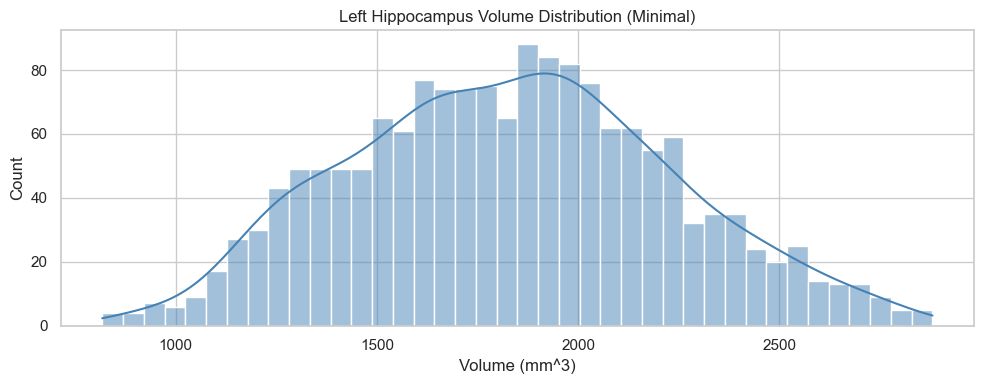

In [63]:
plt.figure(figsize=(10, 4))
sns.histplot(merged["ply_volume_mm3"], bins=40, kde=True, color="steelblue")
plt.title("Left Hippocampus Volume Distribution (Minimal)")
plt.xlabel("Volume (mm^3)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


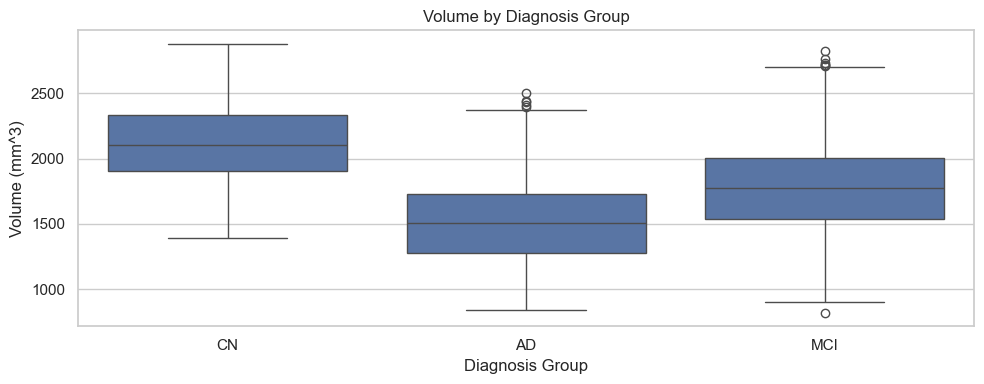

In [64]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=merged, x="diagnosis_group", y="ply_volume_mm3")
plt.title("Volume by Diagnosis Group")
plt.xlabel("Diagnosis Group")
plt.ylabel("Volume (mm^3)")
plt.tight_layout()
plt.show()


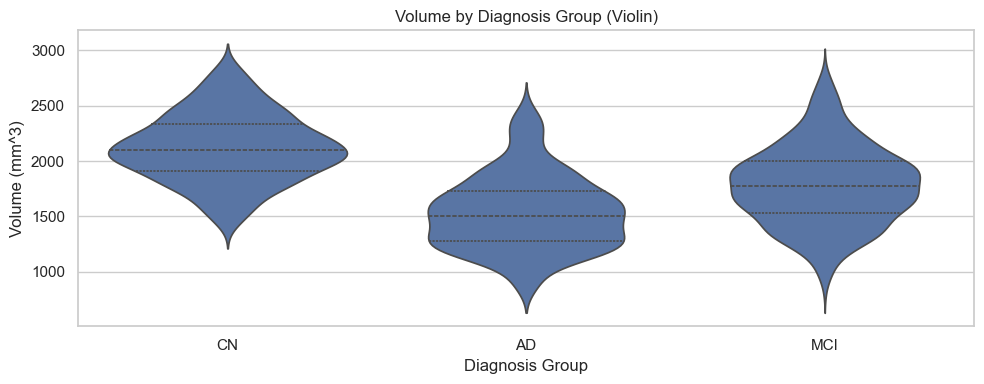

In [65]:
plt.figure(figsize=(10, 4))
sns.violinplot(data=merged, x="diagnosis_group", y="ply_volume_mm3", inner="quartile")
plt.title("Volume by Diagnosis Group (Violin)")
plt.xlabel("Diagnosis Group")
plt.ylabel("Volume (mm^3)")
plt.tight_layout()
plt.show()


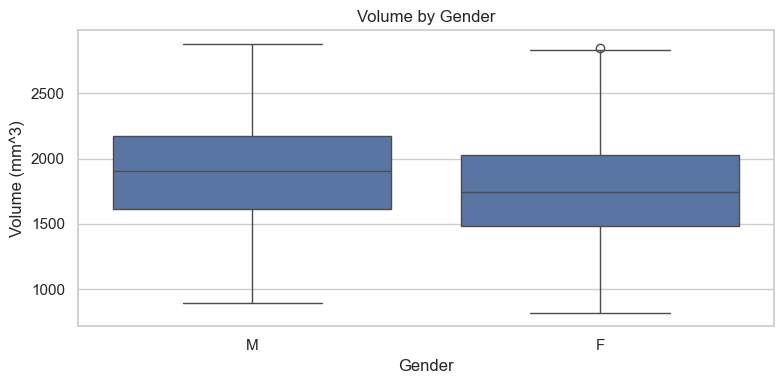

In [66]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=merged, x="gender", y="ply_volume_mm3")
plt.title("Volume by Gender")
plt.xlabel("Gender")
plt.ylabel("Volume (mm^3)")
plt.tight_layout()
plt.show()


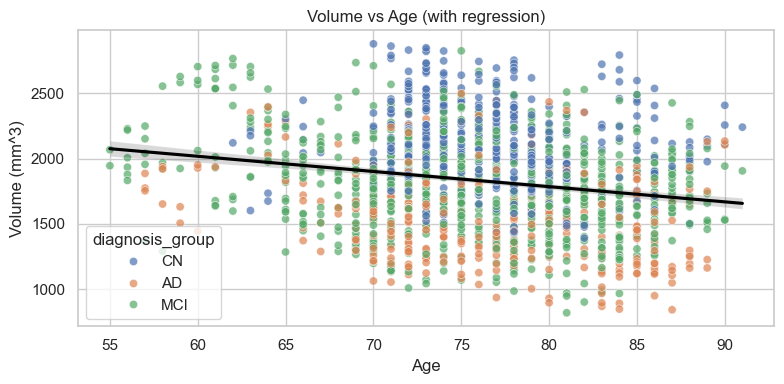

In [67]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=merged, x="age", y="ply_volume_mm3", hue="diagnosis_group", alpha=0.7)
sns.regplot(data=merged, x="age", y="ply_volume_mm3", scatter=False, color="black")
plt.title("Volume vs Age (with regression)")
plt.xlabel("Age")
plt.ylabel("Volume (mm^3)")
plt.tight_layout()
plt.show()


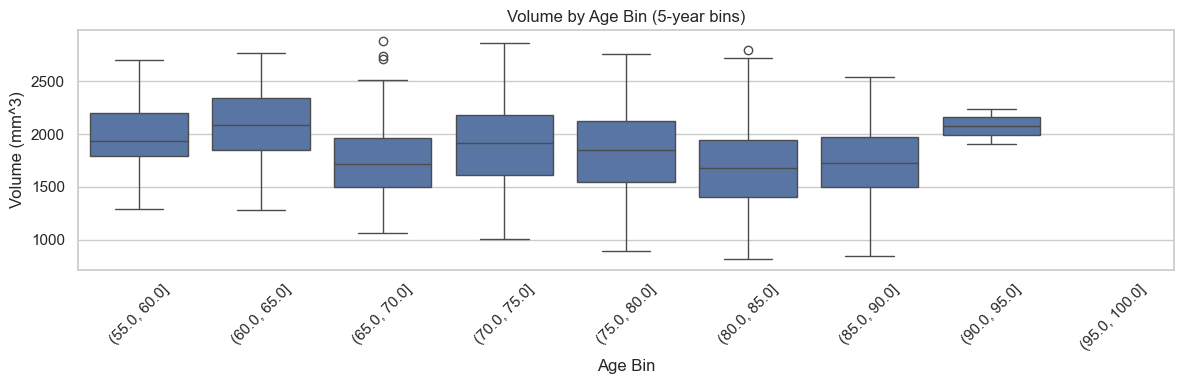

In [68]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=merged, x="age_bin", y="ply_volume_mm3")
plt.title("Volume by Age Bin (5-year bins)")
plt.xlabel("Age Bin")
plt.ylabel("Volume (mm^3)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Average Volume by Exact Age


## Age Coverage and Uncertainty


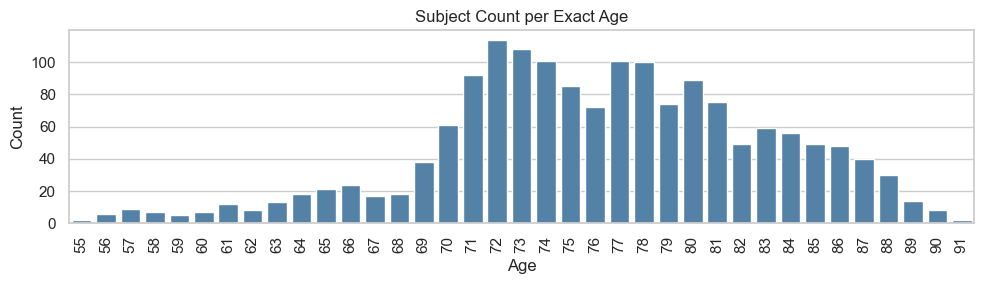

In [69]:
age_counts = merged["age"].value_counts().sort_index()
plt.figure(figsize=(10, 3))
sns.barplot(x=age_counts.index, y=age_counts.values, color="steelblue")
plt.title("Subject Count per Exact Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


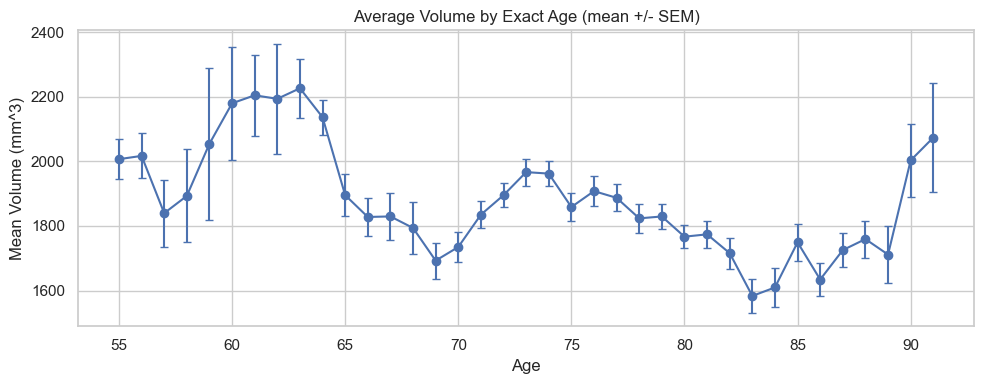

In [70]:
age_stats = (
    merged.dropna(subset=["age"])
    .groupby("age")["ply_volume_mm3"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
age_stats["sem"] = age_stats["std"] / np.sqrt(age_stats["count"])

plt.figure(figsize=(10, 4))
plt.errorbar(
    age_stats["age"],
    age_stats["mean"],
    yerr=age_stats["sem"],
    fmt="o-",
    capsize=3,
)
plt.title("Average Volume by Exact Age (mean +/- SEM)")
plt.xlabel("Age")
plt.ylabel("Mean Volume (mm^3)")
plt.tight_layout()
plt.show()


## Robust Trend Views


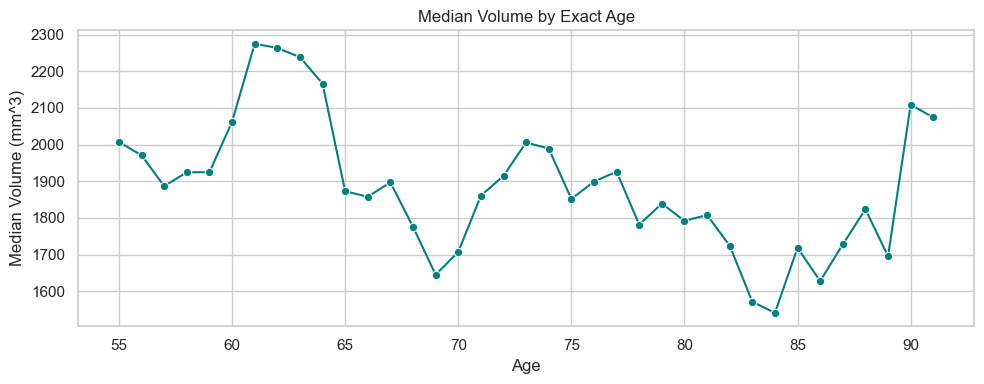

In [71]:
age_median = (
    merged.dropna(subset=["age"])
    .groupby("age")["ply_volume_mm3"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=age_median, x="age", y="ply_volume_mm3", marker="o", color="teal")
plt.title("Median Volume by Exact Age")
plt.xlabel("Age")
plt.ylabel("Median Volume (mm^3)")
plt.tight_layout()
plt.show()


RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

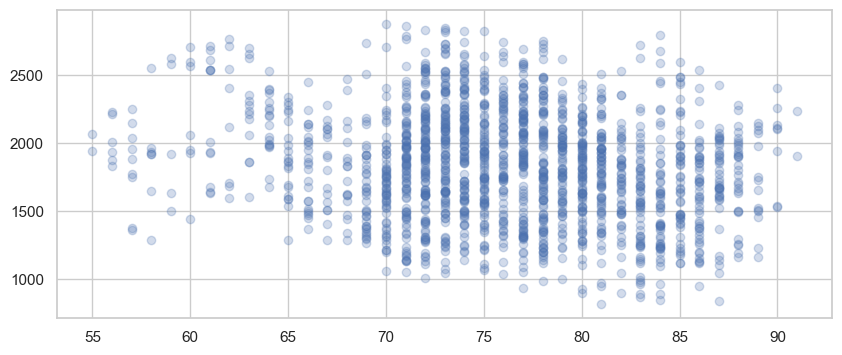

In [72]:
plt.figure(figsize=(10, 4))
sns.regplot(data=merged, x="age", y="ply_volume_mm3",
            scatter_kws={"alpha": 0.25},
            lowess=True, line_kws={"color": "darkred", "linewidth": 2})
plt.title("Volume vs Age (LOWESS Trend)")
plt.xlabel("Age")
plt.ylabel("Volume (mm^3)")
plt.tight_layout()
plt.show()


## Diagnosis Mix by Age


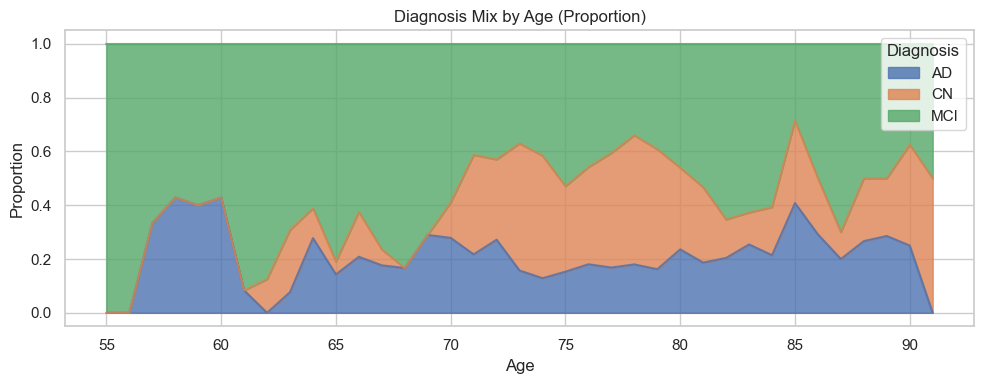

In [73]:
mix_df = merged.dropna(subset=["age", "diagnosis_group"]).copy()
mix_counts = (
    mix_df.groupby(["age", "diagnosis_group"]).size().reset_index(name="count")
)
mix_pivot = mix_counts.pivot(index="age", columns="diagnosis_group", values="count").fillna(0)
mix_pct = mix_pivot.div(mix_pivot.sum(axis=1), axis=0)

mix_pct.plot(kind="area", stacked=True, figsize=(10, 4), alpha=0.8)
plt.title("Diagnosis Mix by Age (Proportion)")
plt.xlabel("Age")
plt.ylabel("Proportion")
plt.legend(title="Diagnosis", loc="upper right")
plt.tight_layout()
plt.show()


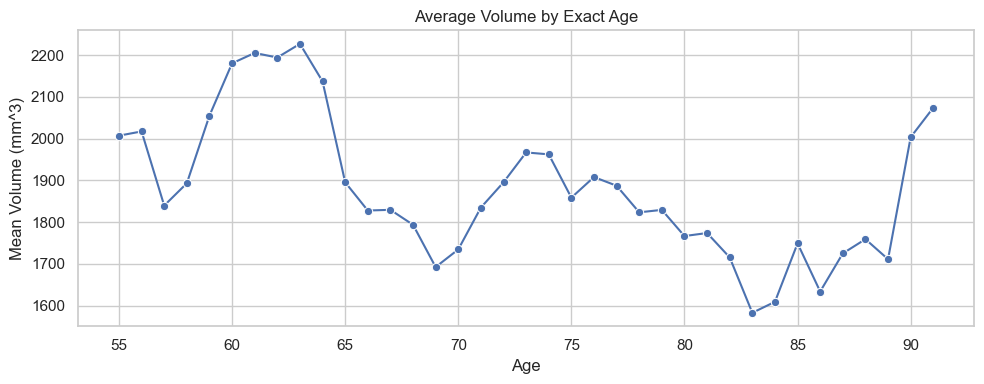

In [74]:
age_avg = (
    merged.dropna(subset=["age"])
    .groupby("age")["ply_volume_mm3"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=age_avg, x="age", y="ply_volume_mm3", marker="o")
plt.title("Average Volume by Exact Age")
plt.xlabel("Age")
plt.ylabel("Mean Volume (mm^3)")
plt.tight_layout()
plt.show()


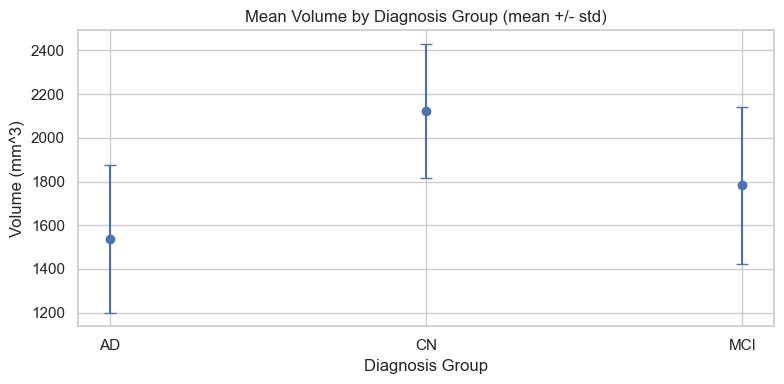

In [75]:
group_stats = merged.groupby("diagnosis_group")["ply_volume_mm3"].agg(["mean", "std", "count"]).reset_index()
plt.figure(figsize=(8, 4))
plt.errorbar(
    group_stats["diagnosis_group"],
    group_stats["mean"],
    yerr=group_stats["std"],
    fmt="o",
    capsize=4,
)
plt.title("Mean Volume by Diagnosis Group (mean +/- std)")
plt.xlabel("Diagnosis Group")
plt.ylabel("Volume (mm^3)")
plt.tight_layout()
plt.show()


## Ground Truth XML Comparison

This section matches PLY volumes to XML ground truth (left hippocampus).


In [76]:
def load_xml_metadata(xml_csv, xml_folder):
    if os.path.exists(xml_csv):
        df = pd.read_csv(xml_csv)
        return df

    import xml.etree.ElementTree as ET

    xml_files = glob(os.path.join(xml_folder, "*.xml"))
    records = []
    for xml_file in tqdm(xml_files, desc="Parsing XML metadata"):
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            ns = {"": "http://www.loni.usc.edu/resource/xml/hippo/v1"}

            rec = {
                "filename": os.path.basename(xml_file).replace(".xml", ""),
                "image_uid": None,
                "left_hippocampus_volume": None,
                "right_hippocampus_volume": None,
            }

            uid_elem = root.find('.//imageUID', ns) or root.find('.//imageUID')
            if uid_elem is not None:
                rec["image_uid"] = uid_elem.text

            derived_measures = root.findall('.//derivedMeasure', ns) or root.findall('.//derivedMeasure')
            for measure in derived_measures:
                structure_elem = measure.find('.//measuredStructure', ns) or measure.find('.//measuredStructure')
                if structure_elem is None or 'Hippocampus' not in structure_elem.text:
                    continue
                hemisphere_elem = measure.find('.//measuredHemisphere', ns) or measure.find('.//measuredHemisphere')
                value_elem = measure.find('.//measureValue', ns) or measure.find('.//measureValue')
                if hemisphere_elem is None or value_elem is None:
                    continue
                try:
                    volume = float(value_elem.text)
                except (ValueError, TypeError):
                    continue
                hemisphere = hemisphere_elem.text.strip()
                if hemisphere == 'Left':
                    rec["left_hippocampus_volume"] = volume
                elif hemisphere == 'Right':
                    rec["right_hippocampus_volume"] = volume

            records.append(rec)
        except Exception:
            continue

    df = pd.DataFrame(records)
    df.to_csv(xml_csv, index=False)
    return df

xml_df = load_xml_metadata(xml_metadata_csv, xml_metadata_path)

# Build image_id key from XML data
xml_df["image_id"] = xml_df.apply(
    lambda r: normalize_image_id(r.get("image_uid")) or extract_image_id(r.get("filename", "")),
    axis=1,
)

xml_df = xml_df.dropna(subset=["image_id", "left_hippocampus_volume"])
print(f"XML records with left volume: {len(xml_df)}")


XML records with left volume: 1632


Parsing site keys:   0%|          | 0/1632 [00:00<?, ?it/s]

Parsing site keys: 100%|██████████| 1632/1632 [00:00<00:00, 5934.61it/s]
/tmp/ipykernel_295762/1194978086.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["site_key", "age_bin_mid"])


Unique site keys: 47


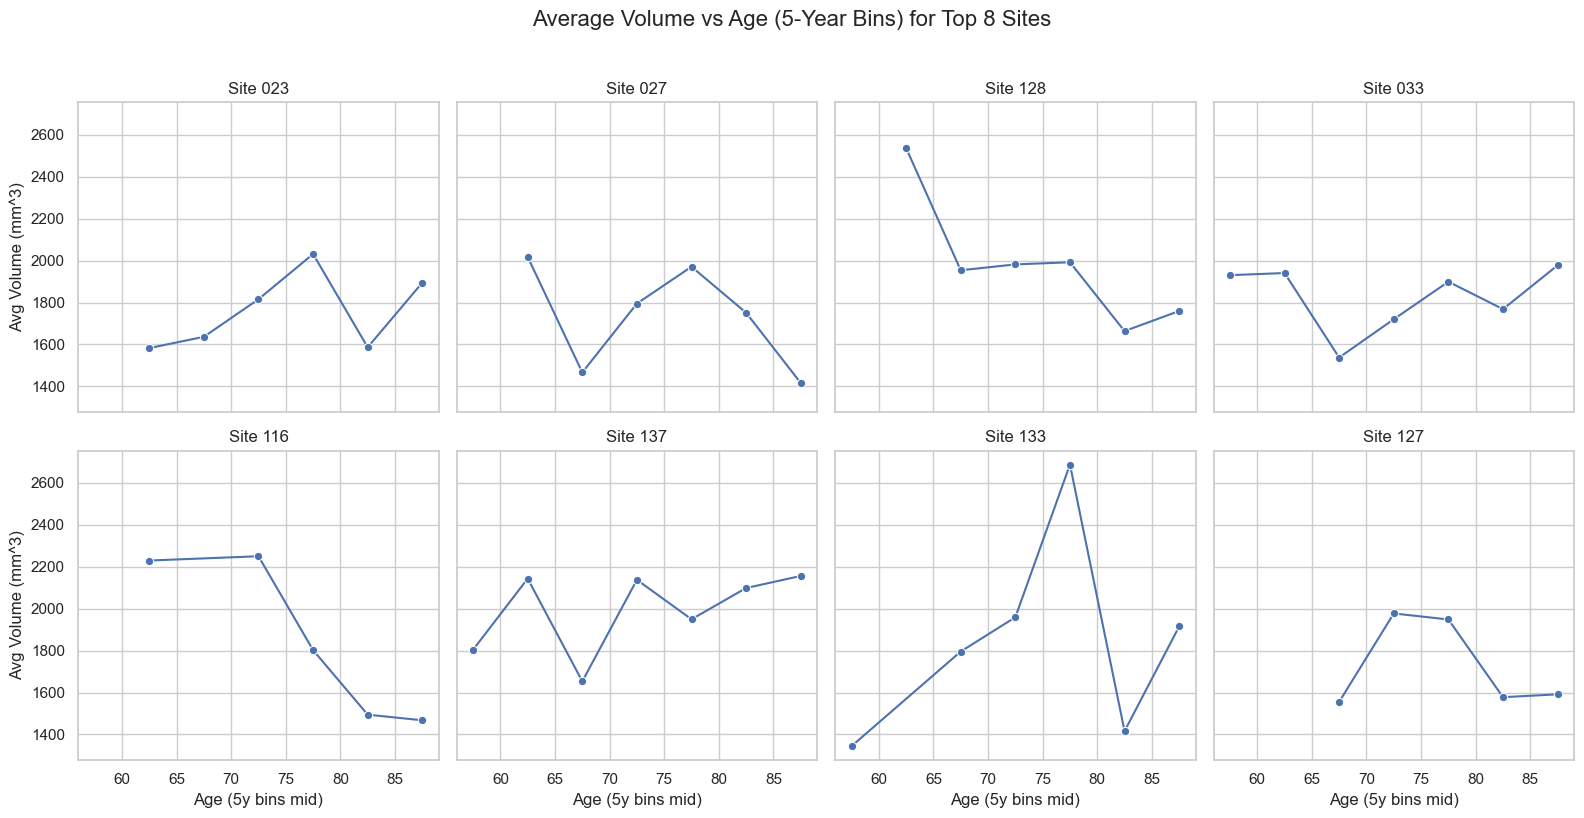

In [77]:
# Site key analysis (ADNI XML)
import xml.etree.ElementTree as ET

def load_sitekeys(xml_folder):
    xml_files = glob(os.path.join(xml_folder, "*.xml"))
    records = []
    for xml_file in tqdm(xml_files, desc="Parsing site keys"):
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()

            site_elem = root.find(".//siteKey") or root.find(".//{*}siteKey")
            site_key = site_elem.text.strip() if site_elem is not None and site_elem.text else None

            image_uid_elem = root.find(".//imageUID") or root.find(".//{*}imageUID")
            image_uid = image_uid_elem.text.strip() if image_uid_elem is not None and image_uid_elem.text else None
            image_id = extract_image_id(os.path.basename(xml_file)) or normalize_image_id(image_uid)

            records.append({
                "image_id": image_id,
                "site_key": site_key,
                "xml_file": os.path.basename(xml_file),
            })
        except Exception:
            continue

    return pd.DataFrame(records)

site_df = load_sitekeys(xml_metadata_path)
site_df = site_df.dropna(subset=["image_id", "site_key"])

print(f"Unique site keys: {site_df['site_key'].nunique()}")
site_df["site_key"].value_counts().head(10)

site_merged = merged.merge(
    site_df[["image_id", "site_key"]],
    how="left",
    on="image_id",
)

site_summary = (
    site_merged.groupby("site_key")["ply_volume_mm3"]
    .agg(["count", "mean", "median", "std"])
    .sort_values(by="count", ascending=False)
)
site_summary.head(10)

def compute_site_slope(group):
    g = group.dropna(subset=["age", "ply_volume_mm3"])
    if len(g) < 3:
        return np.nan
    slope, _ = np.polyfit(g["age"], g["ply_volume_mm3"], 1)
    return slope

site_trends = (
    site_merged.groupby("site_key")
    .apply(compute_site_slope)
    .rename("slope_mm3_per_year")
    .reset_index()
    .merge(site_summary.reset_index(), on="site_key", how="left")
    .sort_values(by="count", ascending=False)
)
site_trends.head(10)

top_sites = site_summary.head(8).index.tolist()
site_plot = site_merged[site_merged["site_key"].isin(top_sites)].copy()

age_series = site_plot["age"].dropna()
if age_series.empty:
    print("No age data available for binning.")
else:
    age_bins = pd.interval_range(
        start=np.floor(age_series.min() / 5) * 5,
        end=np.ceil(age_series.max() / 5) * 5 + 5,
        freq=5,
    )
    site_plot["age_bin"] = pd.cut(site_plot["age"], bins=age_bins)
    site_plot["age_bin_mid"] = site_plot["age_bin"].apply(lambda b: (b.left + b.right) / 2 if pd.notna(b) else np.nan)

    site_age_avg = (
        site_plot.dropna(subset=["age_bin_mid", "ply_volume_mm3"])
        .groupby(["site_key", "age_bin_mid"])
        ["ply_volume_mm3"]
        .mean()
        .reset_index()
    )

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, site in zip(axes, top_sites):
        site_data = site_age_avg[site_age_avg["site_key"] == site]
        if site_data.empty:
            ax.set_title(f"Site {site} (no data)")
            ax.axis("off")
            continue
        sns.lineplot(data=site_data, x="age_bin_mid", y="ply_volume_mm3", marker="o", ax=ax)
        ax.set_title(f"Site {site}")
        ax.set_xlabel("Age (5y bins mid)")
        ax.set_ylabel("Avg Volume (mm^3)")

    for ax in axes[len(top_sites):]:
        ax.axis("off")

    plt.suptitle("Average Volume vs Age (5-Year Bins) for Top 8 Sites", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


In [78]:
compare_df = merged.merge(
    xml_df[["image_id", "left_hippocampus_volume"]],
    how="left",
    on="image_id",
)

compare_df["xml_volume_mm3"] = compare_df["left_hippocampus_volume"]
compare_df["error_mm3"] = compare_df["ply_volume_mm3"] - compare_df["xml_volume_mm3"]
compare_df["error_pct"] = (compare_df["error_mm3"].abs() / compare_df["xml_volume_mm3"]) * 100

compare_df.to_csv(output_xml_csv, index=False)
print(f"Saved XML comparison CSV: {output_xml_csv}")

compare_df[["error_mm3", "error_pct"]].describe()


Saved XML comparison CSV: /home/jakaria/ADNI/ADNI_1/adni_processed/analysis/left_minimal_ply_vs_xml.csv


,error_mm3,error_pct
count,1632.000000,1.632000e+03
mean,0.839505,4.627843e-01
std,11.186896,4.635414e-01
min,-49.596455,4.228907e-07
25%,-4.916494,9.946639e-02
50%,0.002579,3.392796e-01
75%,7.151861,6.951406e-01
max,54.482020,3.180101e+00


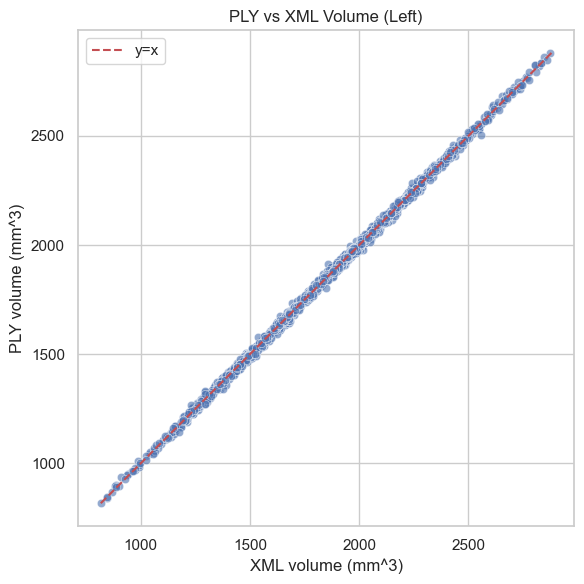

In [79]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=compare_df, x="xml_volume_mm3", y="ply_volume_mm3", alpha=0.6)
min_v = np.nanmin([compare_df["xml_volume_mm3"].min(), compare_df["ply_volume_mm3"].min()])
max_v = np.nanmax([compare_df["xml_volume_mm3"].max(), compare_df["ply_volume_mm3"].max()])
plt.plot([min_v, max_v], [min_v, max_v], "r--", label="y=x")
plt.title("PLY vs XML Volume (Left)")
plt.xlabel("XML volume (mm^3)")
plt.ylabel("PLY volume (mm^3)")
plt.legend()
plt.tight_layout()
plt.show()


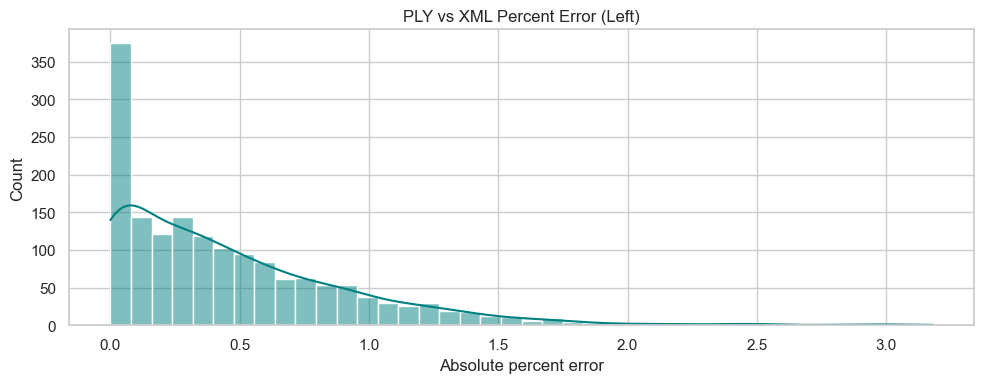

In [80]:
plt.figure(figsize=(10, 4))
sns.histplot(compare_df["error_pct"].dropna(), bins=40, kde=True, color="teal")
plt.title("PLY vs XML Percent Error (Left)")
plt.xlabel("Absolute percent error")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


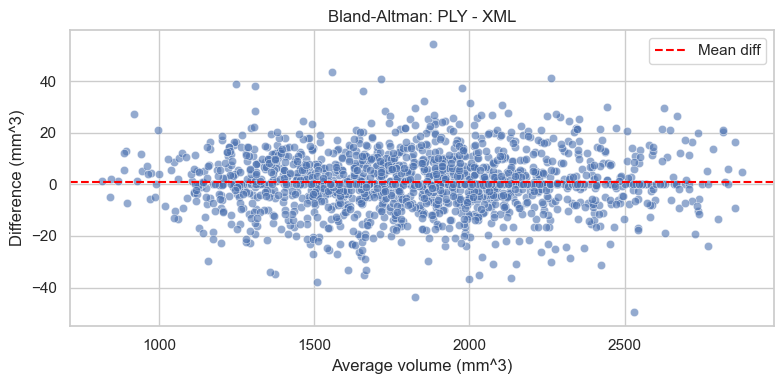

In [81]:
# Bland-Altman style plot
avg_vol = (compare_df["xml_volume_mm3"] + compare_df["ply_volume_mm3"]) / 2
diff_vol = compare_df["ply_volume_mm3"] - compare_df["xml_volume_mm3"]

plt.figure(figsize=(8, 4))
sns.scatterplot(x=avg_vol, y=diff_vol, alpha=0.6)
plt.axhline(diff_vol.mean(), color="red", linestyle="--", label="Mean diff")
plt.title("Bland-Altman: PLY - XML")
plt.xlabel("Average volume (mm^3)")
plt.ylabel("Difference (mm^3)")
plt.legend()
plt.tight_layout()
plt.show()


## Volume Through Age Progression by Diagnosis and Gender

This section visualizes hippocampal volume as a function of age, stratified by diagnosis group (CN, MCI, AD) and gender. It also provides summary analysis for each group.

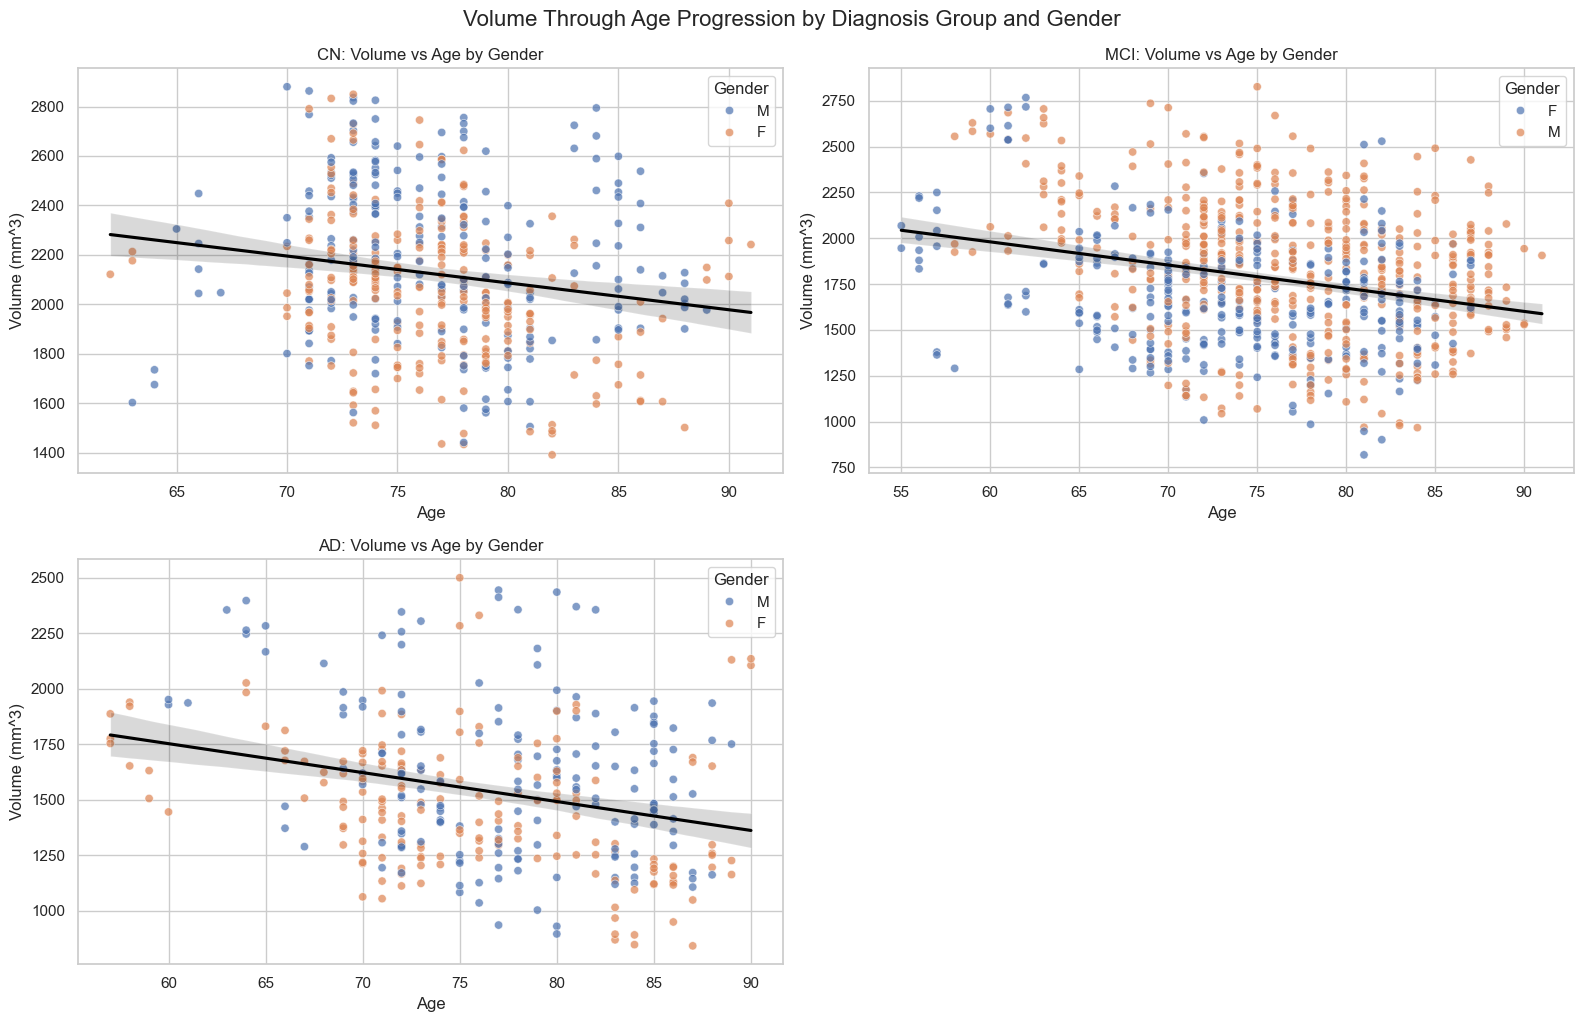

In [82]:
# Volume vs Age progression for each diagnosis group (CN, MCI, AD) separately
import matplotlib.pyplot as plt
import seaborn as sns

diagnosis_groups = ["CN", "MCI", "AD"]
plt.figure(figsize=(16, 10))
for i, group in enumerate(diagnosis_groups, 1):
    plt.subplot(2, 2, i)
    group_df = merged[merged["diagnosis_group"] == group]
    sns.scatterplot(data=group_df, x="age", y="ply_volume_mm3", hue="gender", alpha=0.7)
    sns.regplot(data=group_df, x="age", y="ply_volume_mm3", scatter=False, color="black")
    plt.title(f"{group}: Volume vs Age by Gender")
    plt.xlabel("Age")
    plt.ylabel("Volume (mm^3)")
    plt.legend(title="Gender")
    plt.tight_layout()
plt.suptitle("Volume Through Age Progression by Diagnosis Group and Gender", y=1.02, fontsize=16)
plt.show()

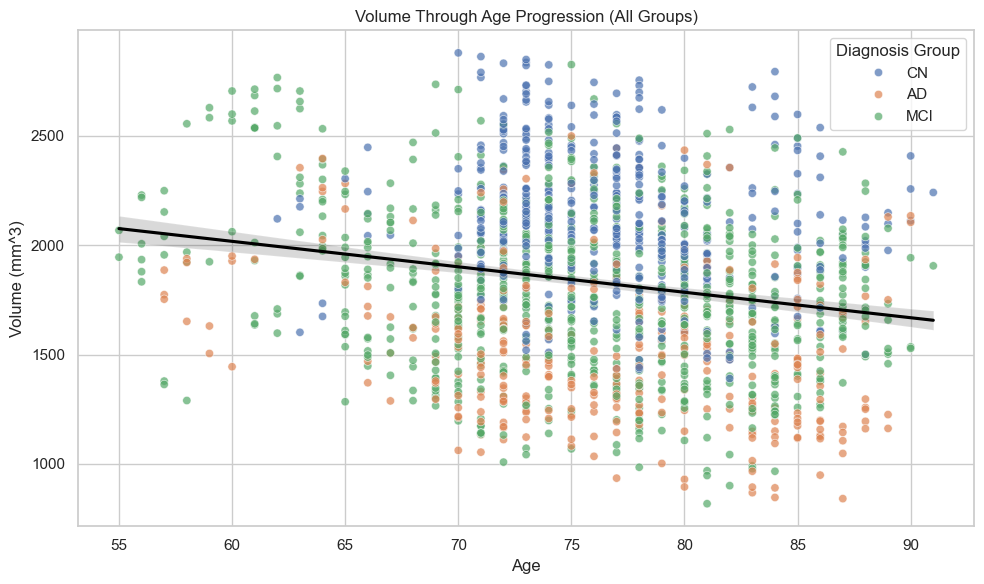

In [83]:
# Volume vs Age progression for all groups together, colored by diagnosis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x="age", y="ply_volume_mm3", hue="diagnosis_group", alpha=0.7)
sns.regplot(data=merged, x="age", y="ply_volume_mm3", scatter=False, color="black")
plt.title("Volume Through Age Progression (All Groups)")
plt.xlabel("Age")
plt.ylabel("Volume (mm^3)")
plt.legend(title="Diagnosis Group")
plt.tight_layout()
plt.show()

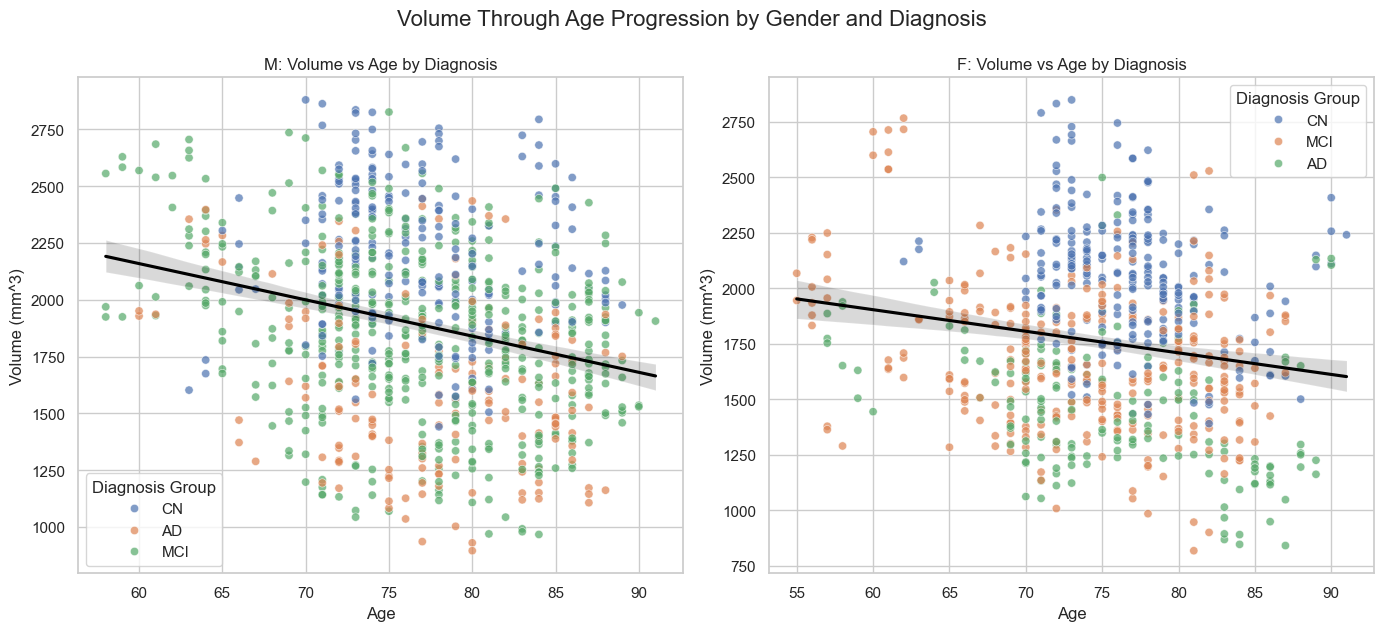

In [84]:
# Gender-based analysis: Volume vs Age for each gender, colored by diagnosis
plt.figure(figsize=(14, 6))
for i, gender in enumerate(["M", "F"], 1):
    plt.subplot(1, 2, i)
    gender_df = merged[merged["gender"] == gender]
    sns.scatterplot(data=gender_df, x="age", y="ply_volume_mm3", hue="diagnosis_group", alpha=0.7)
    sns.regplot(data=gender_df, x="age", y="ply_volume_mm3", scatter=False, color="black")
    plt.title(f"{gender}: Volume vs Age by Diagnosis")
    plt.xlabel("Age")
    plt.ylabel("Volume (mm^3)")
    plt.legend(title="Diagnosis Group")
    plt.tight_layout()
plt.suptitle("Volume Through Age Progression by Gender and Diagnosis", y=1.05, fontsize=16)
plt.show()

In [85]:
# Statistical summary: correlation between age and volume for each group
corr_results = {}
for group in diagnosis_groups:
    group_df = merged[merged["diagnosis_group"] == group]
    if not group_df[["age", "ply_volume_mm3"]].dropna().empty:
        corr = group_df[["age", "ply_volume_mm3"]].corr().iloc[0, 1]
        corr_results[group] = corr
    else:
        corr_results[group] = None
print("Correlation between age and volume (by group):")
for group, corr in corr_results.items():
    print(f"  {group}: {corr:.3f}" if corr is not None else f"  {group}: N/A")

Correlation between age and volume (by group):
  CN: -0.174
  MCI: -0.260
  AD: -0.273


## Average Volume by Age and Diagnosis/Gender


/tmp/ipykernel_295762/2917341603.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_diag.groupby(["age_bin", "diagnosis_group"])


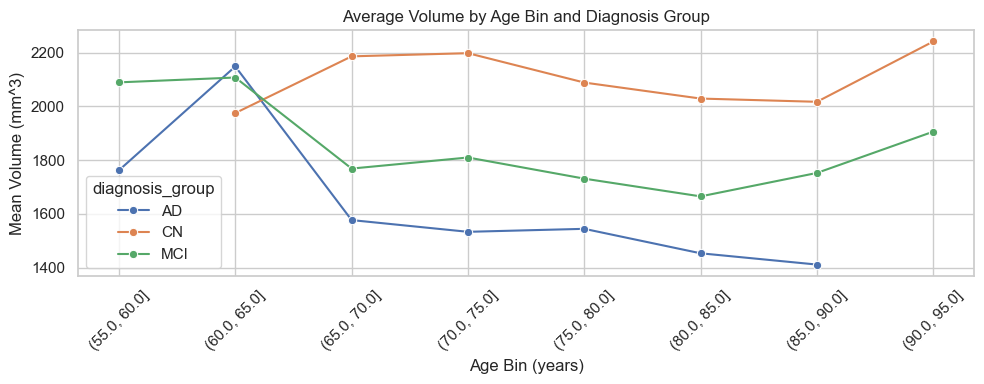

In [86]:
age_series = merged["age"].dropna()
if age_series.empty:
    print("No age data available for binning.")
else:
    age_bins = pd.interval_range(
        start=np.floor(age_series.min() / 5) * 5,
        end=np.ceil(age_series.max() / 5) * 5 + 5,
        freq=5,
    )

    age_diag = merged.dropna(subset=["age", "diagnosis_group"]).copy()
    age_diag["age_bin"] = pd.cut(age_diag["age"], bins=age_bins)

    age_diag = (
        age_diag.groupby(["age_bin", "diagnosis_group"])
        ["ply_volume_mm3"]
        .mean()
        .reset_index()
    )

    age_diag["age_bin_str"] = age_diag["age_bin"].astype(str)
    age_order = [str(x) for x in age_bins]
    age_diag["age_bin_str"] = pd.Categorical(age_diag["age_bin_str"], categories=age_order, ordered=True)
    age_diag = age_diag.sort_values("age_bin_str")

    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=age_diag,
        x="age_bin_str",
        y="ply_volume_mm3",
        hue="diagnosis_group",
        marker="o",
    )
    plt.title("Average Volume by Age Bin and Diagnosis Group")
    plt.xlabel("Age Bin (years)")
    plt.ylabel("Mean Volume (mm^3)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Saved per-scanner age-bin summary: /home/jakaria/ADNI/ADNI_1/adni_processed/analysis/left_minimal_volume_by_age_diag_scanner.csv


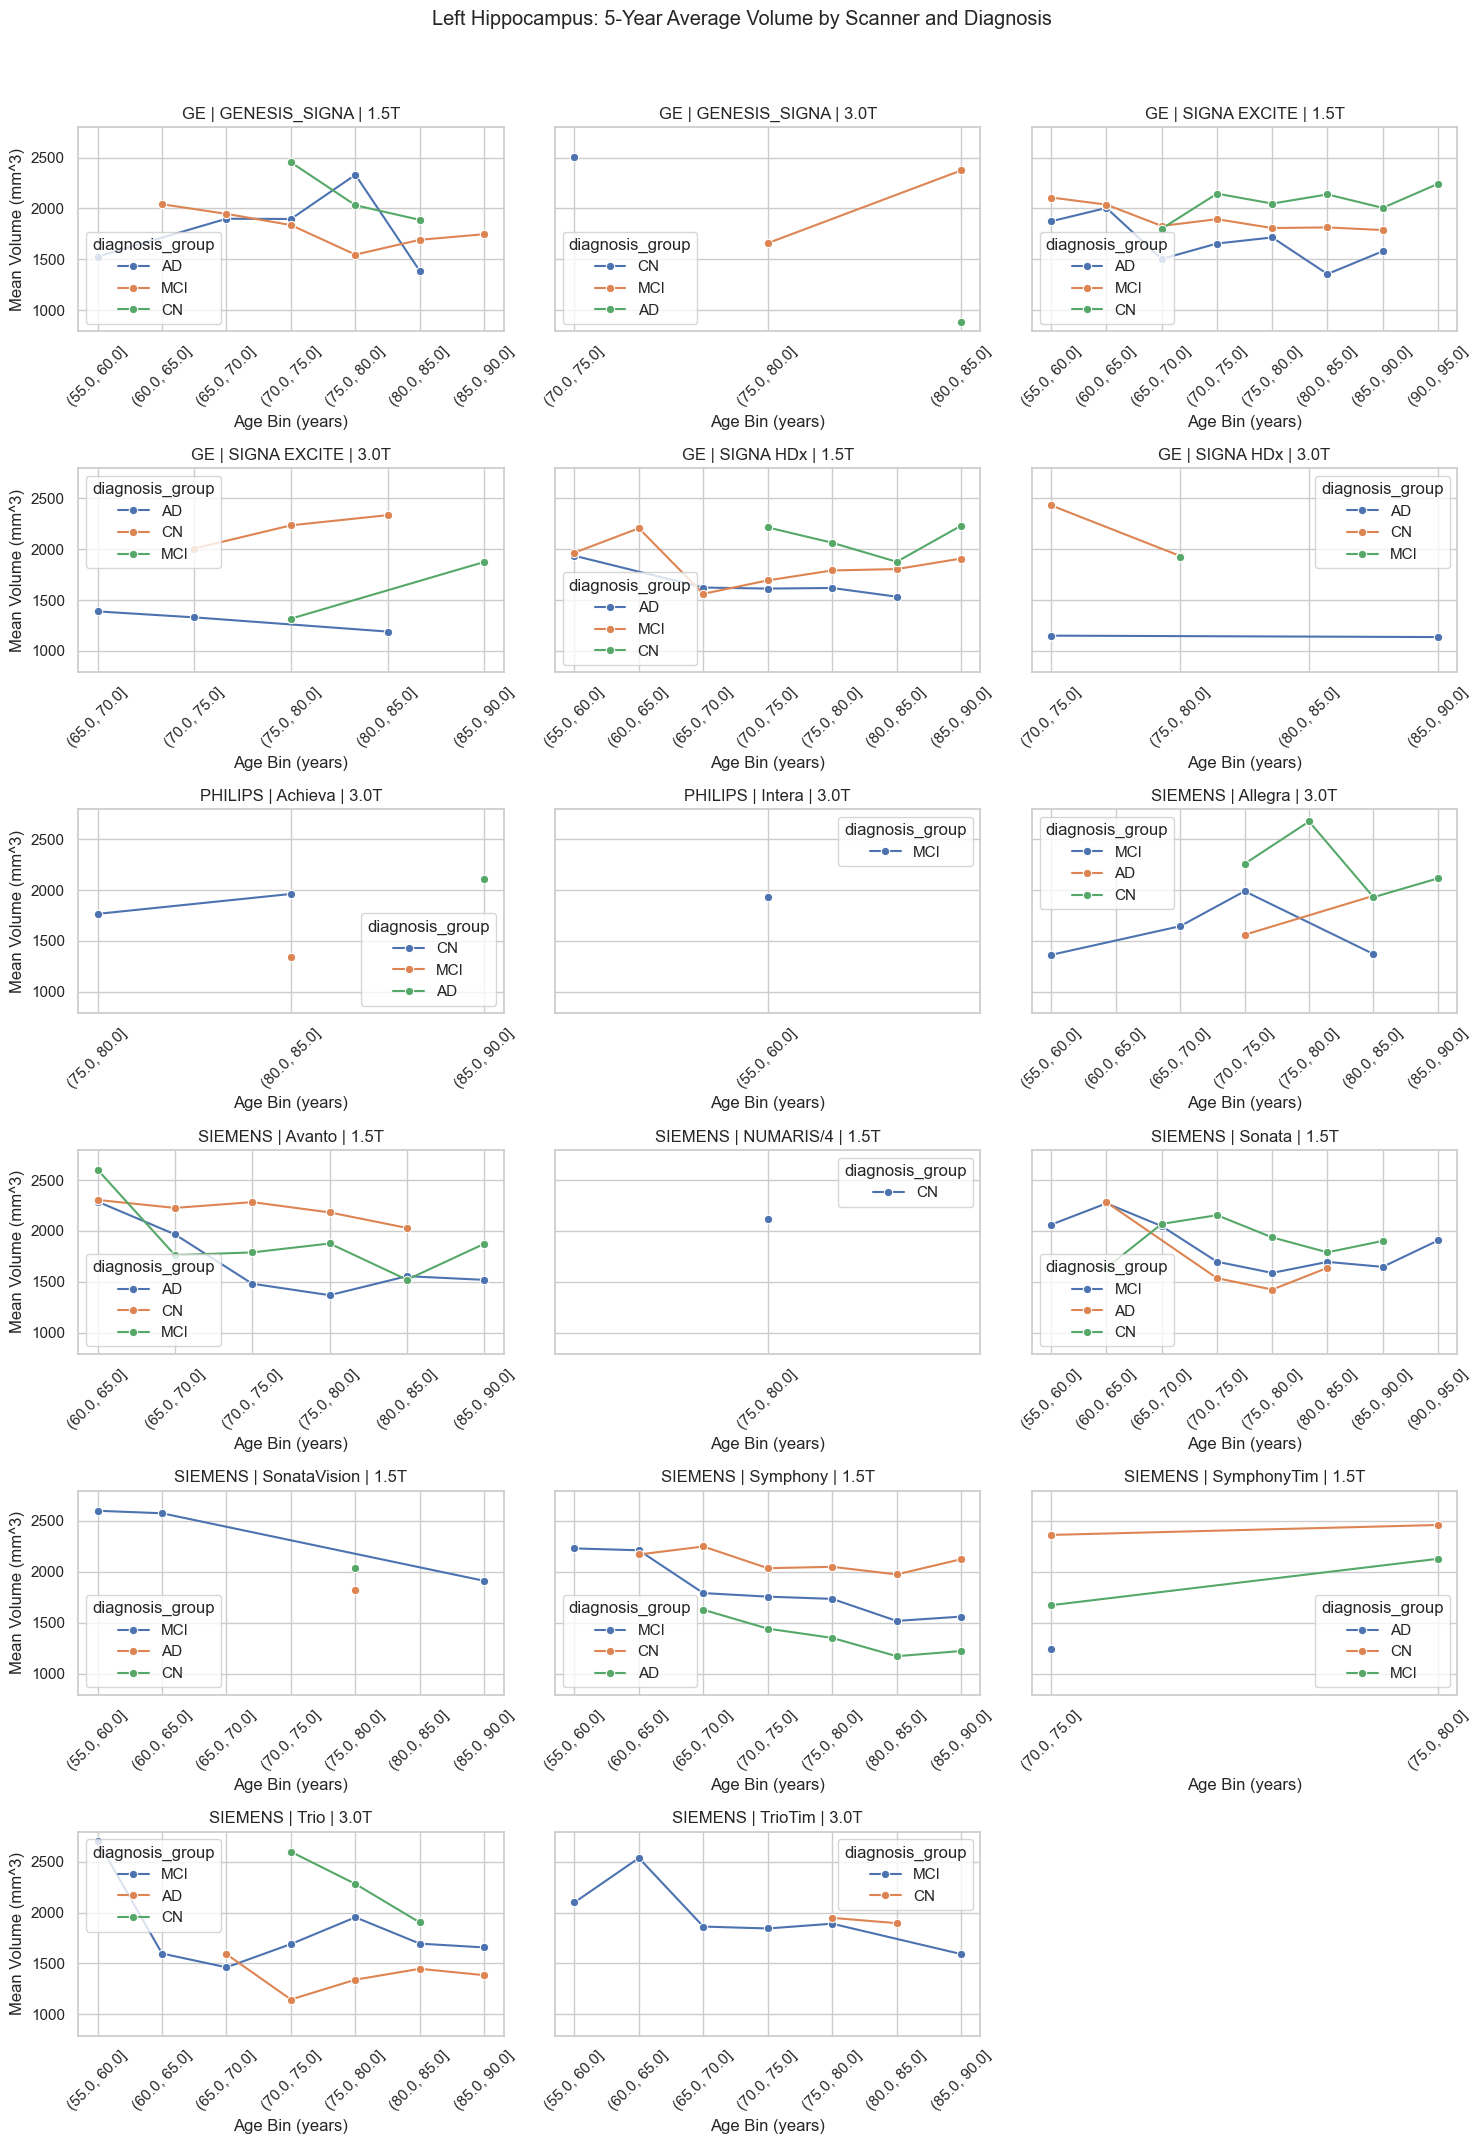

In [88]:
# Per-scanner: 5-year age-bin average LEFT hippocampus volume by diagnosis (AD/CN/MCI)
scanner_csv = "/home/jakaria/ADNI/ADNI_1/All_Subjects_Key_MRI_26Dec2025.csv"

if not os.path.exists(scanner_csv):
    raise FileNotFoundError(f"Missing scanner CSV: {scanner_csv}")

scanner_df = pd.read_csv(scanner_csv)

# Normalize IDs and visit for matching
scanner_df["subject_norm"] = scanner_df["subject_id"].astype(str).str.strip()
scanner_df["visit_norm"] = scanner_df["image_visit"].astype(str).str.lower().str.strip()

# Ensure merged has subject/visit normalized keys
if "subject_id_meta" in merged.columns:
    merged["subject_norm"] = merged["subject_id_meta"].astype(str).str.strip()
else:
    merged["subject_norm"] = merged["subject_id"].astype(str).str.strip()
merged["visit_norm"] = merged["visit"].astype(str).str.lower().str.strip()

# Try to match on image_id if possible (normalize numeric <-> I-prefixed)
def image_id_to_int(val):
    if pd.isna(val):
        return None
    s = str(val).strip()
    if s.startswith("I"):
        s = s[1:]
    if s.endswith(".0"):
        s = s[:-2]
    return int(s) if s.isdigit() else None

scanner_df["image_id_int"] = scanner_df["image_id"].apply(image_id_to_int)
merged["image_id_int"] = merged["image_id"].apply(image_id_to_int)

# Prefer image_id match when possible, otherwise fallback to subject+visit
scanner_cols = [
    "image_id_int",
    "subject_norm",
    "visit_norm",
    "scanner_manufacturer",
    "scanner_model",
    "magnetic_field_strength",
    "software_version",
    "series_type",
    "series_description",
    "image_date",
]
scanner_df = scanner_df[scanner_cols].copy()

# Filter to structural T1w scans (broader than MPRAGE for coverage)
scanner_df = scanner_df[scanner_df["series_type"].eq("T1w")].copy()
scanner_df["image_date_dt"] = pd.to_datetime(scanner_df["image_date"], errors="coerce")

# If multiple scans per subject/visit, keep earliest date
scanner_df = scanner_df.sort_values(["subject_norm", "visit_norm", "image_date_dt"])
scanner_df = scanner_df.drop_duplicates(subset=["subject_norm", "visit_norm"], keep="first")

# First attempt: image_id_int merge
scanner_by_image = scanner_df.dropna(subset=["image_id_int"]).drop_duplicates("image_id_int")
merge_by_image = merged.merge(
    scanner_by_image,
    how="left",
    on="image_id_int",
    suffixes=("", "_scan"),
)

# Fallback: subject+visit merge for rows without scanner info
missing_scanner = merge_by_image["scanner_model"].isna()
if missing_scanner.any():
    fallback = merged.loc[missing_scanner].merge(
        scanner_df,
        how="left",
        on=["subject_norm", "visit_norm"],
        suffixes=("", "_scan"),
    )
    for col in [
        "scanner_manufacturer",
        "scanner_model",
        "magnetic_field_strength",
        "software_version",
        "series_type",
        "series_description",
        "image_date",
    ]:
        merge_by_image.loc[missing_scanner, col] = fallback[col].values

scanner_merged = merge_by_image.copy()

# Build 5-year age bins
age_series = scanner_merged["age"].dropna()
if age_series.empty:
    print("No age data available for binning.")
else:
    age_bins = pd.interval_range(
        start=np.floor(age_series.min() / 5) * 5,
        end=np.ceil(age_series.max() / 5) * 5 + 5,
        freq=5,
    )
    scanner_merged["age_bin"] = pd.cut(scanner_merged["age"], bins=age_bins)

    plot_df = scanner_merged.dropna(
        subset=["age_bin", "diagnosis_group", "ply_volume_mm3", "scanner_model"]
    ).copy()
    plot_df = plot_df[plot_df["diagnosis_group"].isin(["AD", "CN", "MCI"])]

    plot_df["scanner_label"] = (
        plot_df["scanner_manufacturer"].fillna("Unknown") + " | " +
        plot_df["scanner_model"].fillna("Unknown") + " | " +
        plot_df["magnetic_field_strength"].astype(str) + "T"
    )

    age_diag_scanner = (
        plot_df.groupby(["scanner_label", "age_bin", "diagnosis_group"], observed=True)["ply_volume_mm3"]
        .mean()
        .reset_index()
    )

    age_diag_scanner["age_bin_str"] = age_diag_scanner["age_bin"].astype(str)
    age_order = [str(x) for x in age_bins]
    age_diag_scanner["age_bin_str"] = pd.Categorical(
        age_diag_scanner["age_bin_str"], categories=age_order, ordered=True
    )
    age_diag_scanner = age_diag_scanner.sort_values(["scanner_label", "age_bin_str"])

    # Save summary CSV
    per_scanner_csv = os.path.join(analysis_dir, "left_minimal_volume_by_age_diag_scanner.csv")
    age_diag_scanner.to_csv(per_scanner_csv, index=False)
    print(f"Saved per-scanner age-bin summary: {per_scanner_csv}")

    # Plot: one panel per scanner
    scanners = age_diag_scanner["scanner_label"].unique().tolist()
    n = len(scanners)
    if n == 0:
        print("No scanner data available for plotting.")
    else:
        cols = 3
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5), sharey=True)
        axes = np.array(axes).reshape(-1)

        for ax, scanner in zip(axes, scanners):
            sub = age_diag_scanner[age_diag_scanner["scanner_label"] == scanner]
            sns.lineplot(
                data=sub,
                x="age_bin_str",
                y="ply_volume_mm3",
                hue="diagnosis_group",
                marker="o",
                ax=ax,
            )
            ax.set_title(scanner)
            ax.set_xlabel("Age Bin (years)")
            ax.set_ylabel("Mean Volume (mm^3)")
            ax.tick_params(axis="x", rotation=45)

        for ax in axes[len(scanners):]:
            ax.axis("off")

        plt.suptitle("Left Hippocampus: 5-Year Average Volume by Scanner and Diagnosis", y=1.02)
        plt.tight_layout()
        plt.show()


/tmp/ipykernel_295762/3997874569.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender.groupby(["age_bin", "gender"])["ply_volume_mm3"]


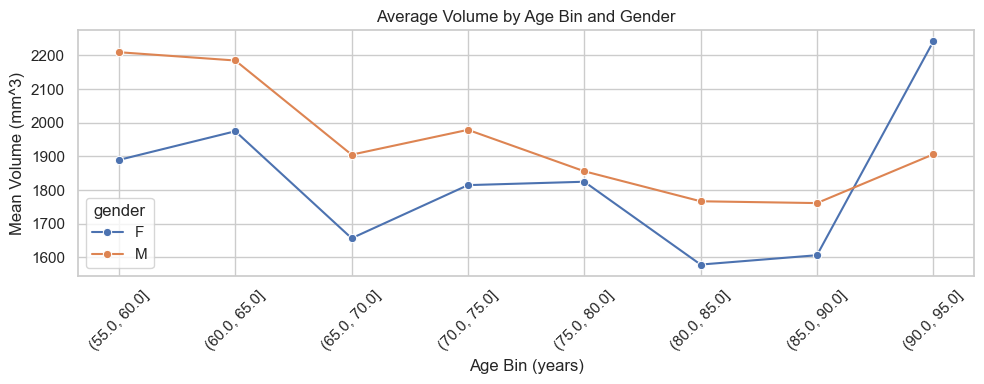

In [89]:
age_series = merged["age"].dropna()
if age_series.empty:
    print("No age data available for binning.")
else:
    age_bins = pd.interval_range(
        start=np.floor(age_series.min() / 5) * 5,
        end=np.ceil(age_series.max() / 5) * 5 + 5,
        freq=5,
    )

    age_gender = merged.dropna(subset=["age", "gender"]).copy()
    age_gender["age_bin"] = pd.cut(age_gender["age"], bins=age_bins)

    age_gender = (
        age_gender.groupby(["age_bin", "gender"])["ply_volume_mm3"]
        .mean()
        .reset_index()
    )

    age_gender["age_bin_str"] = age_gender["age_bin"].astype(str)
    age_order = [str(x) for x in age_bins]
    age_gender["age_bin_str"] = pd.Categorical(age_gender["age_bin_str"], categories=age_order, ordered=True)
    age_gender = age_gender.sort_values("age_bin_str")

    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=age_gender,
        x="age_bin_str",
        y="ply_volume_mm3",
        hue="gender",
        marker="o",
    )
    plt.title("Average Volume by Age Bin and Gender")
    plt.xlabel("Age Bin (years)")
    plt.ylabel("Mean Volume (mm^3)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Average Volume by 5-Year Age Bin (Diagnosis/Gender)


/tmp/ipykernel_295762/127215176.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_diag.groupby(["age_bin", "diagnosis_group"])


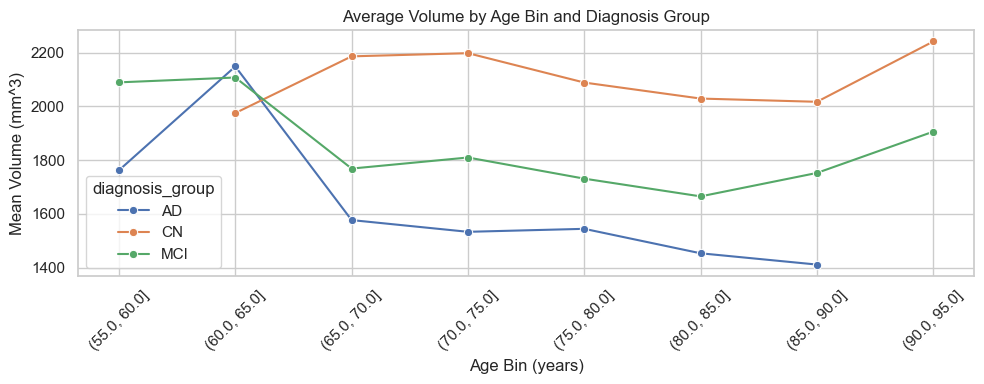

In [90]:
age_series = merged["age"].dropna()
if age_series.empty:
    print("No age data available for binning.")
else:
    age_bins = pd.interval_range(
        start=np.floor(age_series.min() / 5) * 5,
        end=np.ceil(age_series.max() / 5) * 5 + 5,
        freq=5,
    )

    age_diag = merged.dropna(subset=["age", "diagnosis_group"]).copy()
    age_diag["age_bin"] = pd.cut(age_diag["age"], bins=age_bins)
    age_diag = (
        age_diag.groupby(["age_bin", "diagnosis_group"])
        ["ply_volume_mm3"]
        .mean()
        .reset_index()
    )

    age_diag["age_bin_str"] = age_diag["age_bin"].astype(str)
    age_order = [str(x) for x in age_bins]
    age_diag["age_bin_str"] = pd.Categorical(age_diag["age_bin_str"], categories=age_order, ordered=True)
    age_diag = age_diag.sort_values("age_bin_str")

    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=age_diag,
        x="age_bin_str",
        y="ply_volume_mm3",
        hue="diagnosis_group",
        marker="o",
    )
    plt.title("Average Volume by Age Bin and Diagnosis Group")
    plt.xlabel("Age Bin (years)")
    plt.ylabel("Mean Volume (mm^3)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_295762/3452335218.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender.groupby(["age_bin", "gender"])["ply_volume_mm3"]


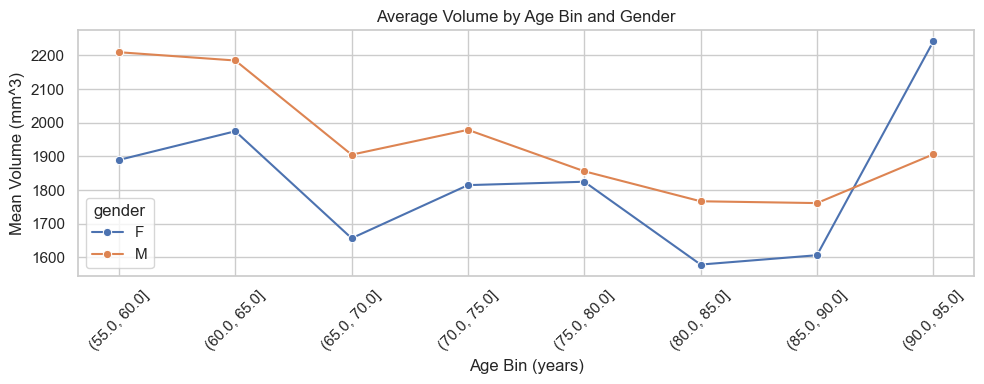

In [91]:
age_series = merged["age"].dropna()
if age_series.empty:
    print("No age data available for binning.")
else:
    age_bins = pd.interval_range(
        start=np.floor(age_series.min() / 5) * 5,
        end=np.ceil(age_series.max() / 5) * 5 + 5,
        freq=5,
    )

    age_gender = merged.dropna(subset=["age", "gender"]).copy()
    age_gender["age_bin"] = pd.cut(age_gender["age"], bins=age_bins)
    age_gender = (
        age_gender.groupby(["age_bin", "gender"])["ply_volume_mm3"]
        .mean()
        .reset_index()
    )

    age_gender["age_bin_str"] = age_gender["age_bin"].astype(str)
    age_order = [str(x) for x in age_bins]
    age_gender["age_bin_str"] = pd.Categorical(age_gender["age_bin_str"], categories=age_order, ordered=True)
    age_gender = age_gender.sort_values("age_bin_str")

    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=age_gender,
        x="age_bin_str",
        y="ply_volume_mm3",
        hue="gender",
        marker="o",
    )
    plt.title("Average Volume by Age Bin and Gender")
    plt.xlabel("Age Bin (years)")
    plt.ylabel("Mean Volume (mm^3)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Per-Scanner, Per-Diagnosis, Per-Age-Bin (5y) Average Left Hippocampus Volume

This section integrates scanner information from `All_Subjects_Key_MRI_26Dec2025.csv` and computes the average left hippocampus volume for each scanner, diagnosis group (AD, CN, MCI), and 5-year age bin. The results are visualized and saved as a summary CSV.

Saved per-scanner age-bin summary: /home/jakaria/ADNI/ADNI_1/adni_processed/analysis/left_minimal_volume_by_age_diag_scanner.csv


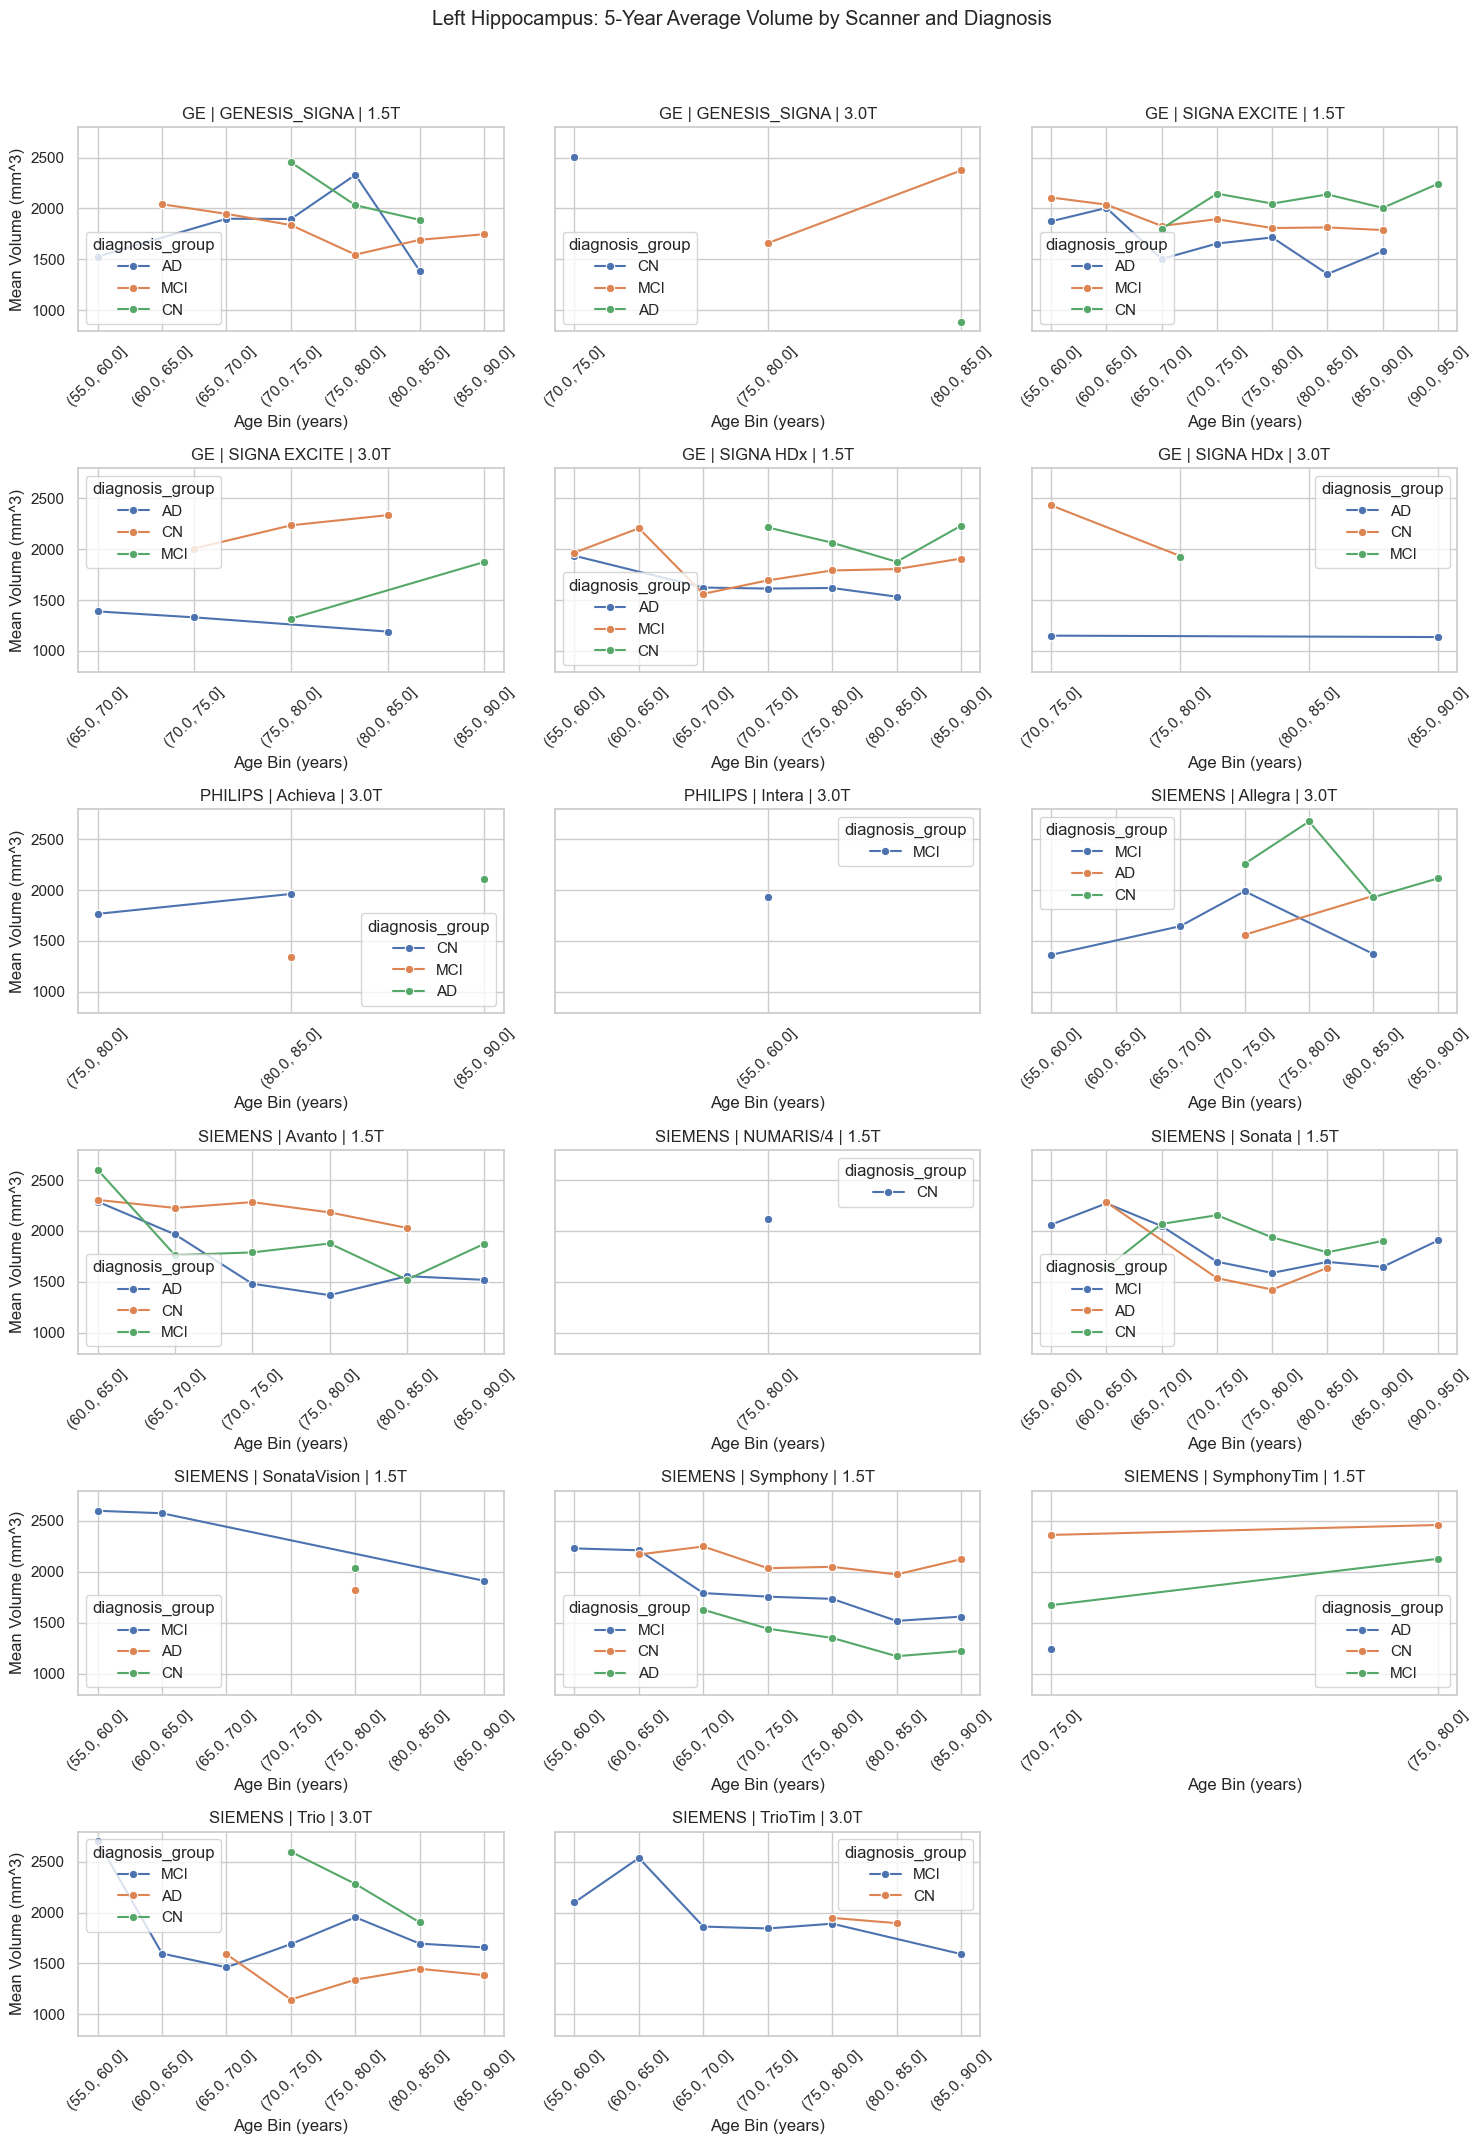

In [92]:
# Per-scanner: 5-year age-bin average LEFT hippocampus volume by diagnosis (AD/CN/MCI)
scanner_csv = "/home/jakaria/ADNI/ADNI_1/All_Subjects_Key_MRI_26Dec2025.csv"

if not os.path.exists(scanner_csv):
    raise FileNotFoundError(f"Missing scanner CSV: {scanner_csv}")

scanner_df = pd.read_csv(scanner_csv)

# Normalize IDs and visit for matching
scanner_df["subject_norm"] = scanner_df["subject_id"].astype(str).str.strip()
scanner_df["visit_norm"] = scanner_df["image_visit"].astype(str).str.lower().str.strip()

# Ensure merged has subject/visit normalized keys
if "subject_id_meta" in merged.columns:
    merged["subject_norm"] = merged["subject_id_meta"].astype(str).str.strip()
else:
    merged["subject_norm"] = merged["subject_id"].astype(str).str.strip()
merged["visit_norm"] = merged["visit"].astype(str).str.lower().str.strip()

# Try to match on image_id if possible (normalize numeric <-> I-prefixed)
def image_id_to_int(val):
    if pd.isna(val):
        return None
    s = str(val).strip()
    if s.startswith("I"):
        s = s[1:]
    if s.endswith(".0"):
        s = s[:-2]
    return int(s) if s.isdigit() else None

scanner_df["image_id_int"] = scanner_df["image_id"].apply(image_id_to_int)
merged["image_id_int"] = merged["image_id"].apply(image_id_to_int)

# Prefer image_id match when possible, otherwise fallback to subject+visit
scanner_cols = [
    "image_id_int",
    "subject_norm",
    "visit_norm",
    "scanner_manufacturer",
    "scanner_model",
    "magnetic_field_strength",
    "software_version",
    "series_type",
    "series_description",
    "image_date",
]
scanner_df = scanner_df[scanner_cols].copy()

# Filter to structural T1w scans (broader than MPRAGE for coverage)
scanner_df = scanner_df[scanner_df["series_type"].eq("T1w")].copy()
scanner_df["image_date_dt"] = pd.to_datetime(scanner_df["image_date"], errors="coerce")

# If multiple scans per subject/visit, keep earliest date
scanner_df = scanner_df.sort_values(["subject_norm", "visit_norm", "image_date_dt"])
scanner_df = scanner_df.drop_duplicates(subset=["subject_norm", "visit_norm"], keep="first")

# First attempt: image_id_int merge
scanner_by_image = scanner_df.dropna(subset=["image_id_int"]).drop_duplicates("image_id_int")
merge_by_image = merged.merge(
    scanner_by_image,
    how="left",
    on="image_id_int",
    suffixes=("", "_scan"),
)

# Fallback: subject+visit merge for rows without scanner info
missing_scanner = merge_by_image["scanner_model"].isna()
if missing_scanner.any():
    fallback = merged.loc[missing_scanner].merge(
        scanner_df,
        how="left",
        on=["subject_norm", "visit_norm"],
        suffixes=("", "_scan"),
    )
    for col in [
        "scanner_manufacturer",
        "scanner_model",
        "magnetic_field_strength",
        "software_version",
        "series_type",
        "series_description",
        "image_date",
    ]:
        merge_by_image.loc[missing_scanner, col] = fallback[col].values

scanner_merged = merge_by_image.copy()

# Build 5-year age bins
age_series = scanner_merged["age"].dropna()
if age_series.empty:
    print("No age data available for binning.")
else:
    age_bins = pd.interval_range(
        start=np.floor(age_series.min() / 5) * 5,
        end=np.ceil(age_series.max() / 5) * 5 + 5,
        freq=5,
    )
    scanner_merged["age_bin"] = pd.cut(scanner_merged["age"], bins=age_bins)

    plot_df = scanner_merged.dropna(
        subset=["age_bin", "diagnosis_group", "ply_volume_mm3", "scanner_model"]
    ).copy()
    plot_df = plot_df[plot_df["diagnosis_group"].isin(["AD", "CN", "MCI"])]

    plot_df["scanner_label"] = (
        plot_df["scanner_manufacturer"].fillna("Unknown") + " | " +
        plot_df["scanner_model"].fillna("Unknown") + " | " +
        plot_df["magnetic_field_strength"].astype(str) + "T"
    )

    age_diag_scanner = (
        plot_df.groupby(["scanner_label", "age_bin", "diagnosis_group"], observed=True)["ply_volume_mm3"]
        .mean()
        .reset_index()
    )

    age_diag_scanner["age_bin_str"] = age_diag_scanner["age_bin"].astype(str)
    age_order = [str(x) for x in age_bins]
    age_diag_scanner["age_bin_str"] = pd.Categorical(
        age_diag_scanner["age_bin_str"], categories=age_order, ordered=True
    )
    age_diag_scanner = age_diag_scanner.sort_values(["scanner_label", "age_bin_str"])

    # Save summary CSV
    per_scanner_csv = os.path.join(analysis_dir, "left_minimal_volume_by_age_diag_scanner.csv")
    age_diag_scanner.to_csv(per_scanner_csv, index=False)
    print(f"Saved per-scanner age-bin summary: {per_scanner_csv}")

    # Plot: one panel per scanner
    scanners = age_diag_scanner["scanner_label"].unique().tolist()
    n = len(scanners)
    if n == 0:
        print("No scanner data available for plotting.")
    else:
        cols = 3
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5), sharey=True)
        axes = np.array(axes).reshape(-1)

        for ax, scanner in zip(axes, scanners):
            sub = age_diag_scanner[age_diag_scanner["scanner_label"] == scanner]
            sns.lineplot(
                data=sub,
                x="age_bin_str",
                y="ply_volume_mm3",
                hue="diagnosis_group",
                marker="o",
                ax=ax,
            )
            ax.set_title(scanner)
            ax.set_xlabel("Age Bin (years)")
            ax.set_ylabel("Mean Volume (mm^3)")
            ax.tick_params(axis="x", rotation=45)

        for ax in axes[len(scanners):]:
            ax.axis("off")

        plt.suptitle("Left Hippocampus: 5-Year Average Volume by Scanner and Diagnosis", y=1.02)
        plt.tight_layout()
        plt.show()

## Per-Vendor (Manufacturer), Per-Diagnosis, Per-Age-Bin (5y) Average Left Hippocampus Volume

This section groups all scanner models under each manufacturer (e.g., GE, PHILIPS, SIEMENS, etc.) and computes the average left hippocampus volume for each vendor, diagnosis group (AD, CN, MCI), and 5-year age bin. Each vendor gets a separate plot showing the trend for each diagnosis group.

Saved per-vendor age-bin summary: /home/jakaria/ADNI/ADNI_1/adni_processed/analysis/left_minimal_volume_by_age_diag_vendor.csv


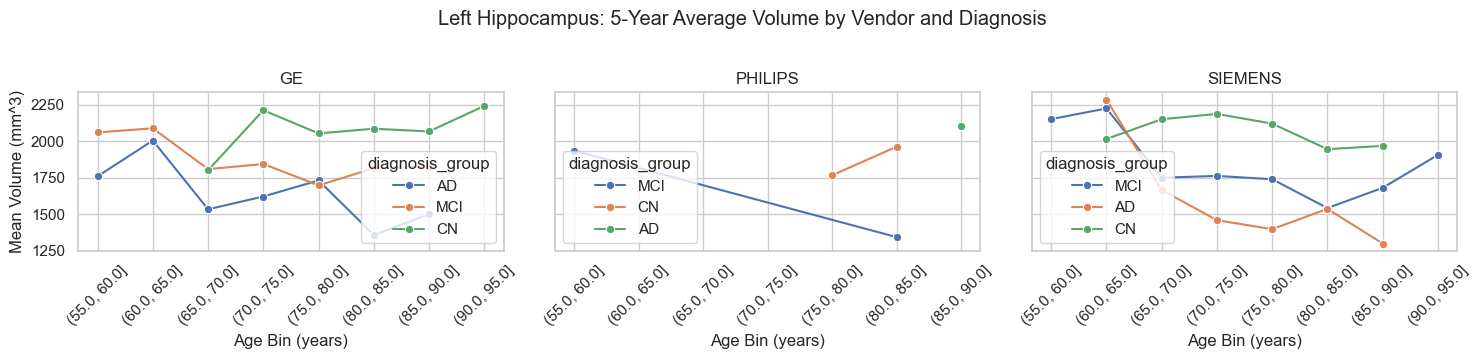

In [93]:
# Per-vendor: 5-year age-bin average LEFT hippocampus volume by diagnosis (AD/CN/MCI)
if age_series.empty:
    print("No age data available for binning.")
else:
    vendor_df = scanner_merged.dropna(subset=["age_bin", "diagnosis_group", "ply_volume_mm3", "scanner_manufacturer"])
    vendor_df = vendor_df[vendor_df["diagnosis_group"].isin(["AD", "CN", "MCI"])]
    vendor_df["vendor"] = vendor_df["scanner_manufacturer"].fillna("Unknown").str.upper()

    age_diag_vendor = (
        vendor_df.groupby(["vendor", "age_bin", "diagnosis_group"], observed=True)["ply_volume_mm3"]
        .mean()
        .reset_index()
    )
    age_diag_vendor["age_bin_str"] = age_diag_vendor["age_bin"].astype(str)
    age_order = [str(x) for x in age_bins]
    age_diag_vendor["age_bin_str"] = pd.Categorical(
        age_diag_vendor["age_bin_str"], categories=age_order, ordered=True
    )
    age_diag_vendor = age_diag_vendor.sort_values(["vendor", "age_bin_str"])

    # Save summary CSV
    per_vendor_csv = os.path.join(analysis_dir, "left_minimal_volume_by_age_diag_vendor.csv")
    age_diag_vendor.to_csv(per_vendor_csv, index=False)
    print(f"Saved per-vendor age-bin summary: {per_vendor_csv}")

    # Plot: one panel per vendor
    vendors = age_diag_vendor["vendor"].unique().tolist()
    n = len(vendors)
    if n == 0:
        print("No vendor data available for plotting.")
    else:
        cols = 2 if n <= 2 else 3
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5), sharey=True)
        axes = np.array(axes).reshape(-1)

        for ax, vendor in zip(axes, vendors):
            sub = age_diag_vendor[age_diag_vendor["vendor"] == vendor]
            sns.lineplot(
                data=sub,
                x="age_bin_str",
                y="ply_volume_mm3",
                hue="diagnosis_group",
                marker="o",
                ax=ax,
            )
            ax.set_title(vendor)
            ax.set_xlabel("Age Bin (years)")
            ax.set_ylabel("Mean Volume (mm^3)")
            ax.tick_params(axis="x", rotation=45)

        for ax in axes[len(vendors):]:
            ax.axis("off")

        plt.suptitle("Left Hippocampus: 5-Year Average Volume by Vendor and Diagnosis", y=1.02)
        plt.tight_layout()
        plt.show()

## ComBat Harmonization: Assessing Scanner/Vendor Effect

This cell uses ComBat to harmonize left hippocampus volumes across vendors and visualizes the effect before and after harmonization. This helps assess whether scanner/vendor introduces systematic differences.

Loaded merged data from /home/jakaria/ADNI/ADNI_1/adni_processed/analysis/left_minimal_ply_volume_analysis.csv


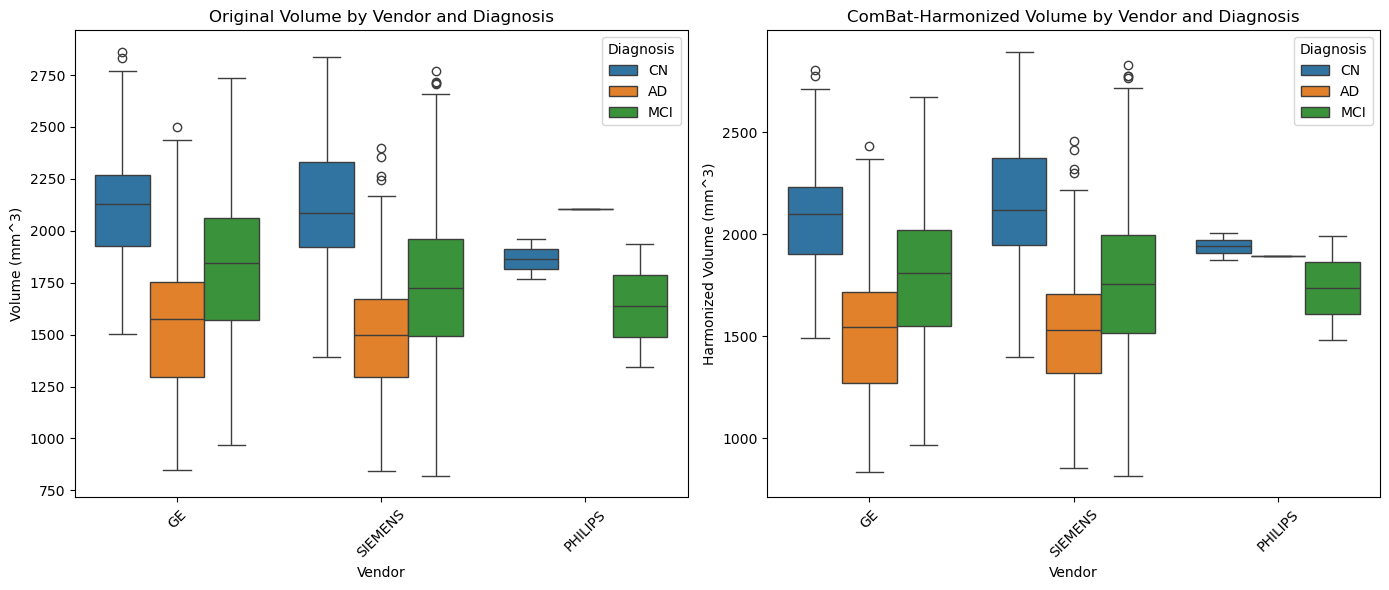

In [2]:
# --- ComBat Harmonization: Clean, Correct Version ---
import os
import numpy as np
import pandas as pd
from neuroHarmonize import harmonizationLearn

# Ensure merged data is available
if "merged" not in globals():
    base_dir = "/home/jakaria/ADNI/ADNI_1/adni_processed"
    analysis_dir = os.path.join(base_dir, "analysis")
    fallback_csv = os.path.join(analysis_dir, "left_minimal_ply_volume_analysis.csv")
    if os.path.exists(fallback_csv):
        merged = pd.read_csv(fallback_csv)
        print(f"Loaded merged data from {fallback_csv}")
    else:
        print("Missing merged data; run earlier cells to build it.")
        merged = None

if merged is None:
    print("Skipping ComBat: merged data unavailable.")
else:
    # Build scanner_merged if needed
    if "scanner_merged" not in globals():
        scanner_csv = "/home/jakaria/ADNI/ADNI_1/All_Subjects_Key_MRI_26Dec2025.csv"
        if not os.path.exists(scanner_csv):
            print(f"Missing scanner CSV: {scanner_csv}")
            scanner_merged = None
        else:
            scanner_df = pd.read_csv(scanner_csv)

            scanner_df["subject_norm"] = scanner_df["subject_id"].astype(str).str.strip()
            scanner_df["visit_norm"] = scanner_df["image_visit"].astype(str).str.lower().str.strip()

            if "subject_id_meta" in merged.columns:
                merged["subject_norm"] = merged["subject_id_meta"].astype(str).str.strip()
            else:
                merged["subject_norm"] = merged["subject_id"].astype(str).str.strip()
            merged["visit_norm"] = merged["visit"].astype(str).str.lower().str.strip()

            def image_id_to_int(val):
                if pd.isna(val):
                    return None
                s = str(val).strip()
                if s.startswith("I"):
                    s = s[1:]
                if s.endswith(".0"):
                    s = s[:-2]
                return int(s) if s.isdigit() else None

            scanner_df["image_id_int"] = scanner_df["image_id"].apply(image_id_to_int)
            merged["image_id_int"] = merged["image_id"].apply(image_id_to_int)

            scanner_cols = [
                "image_id_int",
                "subject_norm",
                "visit_norm",
                "scanner_manufacturer",
                "scanner_model",
                "magnetic_field_strength",
                "software_version",
                "series_type",
                "series_description",
                "image_date",
            ]
            scanner_df = scanner_df[scanner_cols].copy()

            scanner_df = scanner_df[scanner_df["series_type"].eq("T1w")].copy()
            scanner_df["image_date_dt"] = pd.to_datetime(scanner_df["image_date"], errors="coerce")
            scanner_df = scanner_df.sort_values(["subject_norm", "visit_norm", "image_date_dt"])
            scanner_df = scanner_df.drop_duplicates(subset=["subject_norm", "visit_norm"], keep="first")

            scanner_by_image = scanner_df.dropna(subset=["image_id_int"]).drop_duplicates("image_id_int")
            merge_by_image = merged.merge(
                scanner_by_image,
                how="left",
                on="image_id_int",
                suffixes=("", "_scan"),
            )

            missing_scanner = merge_by_image["scanner_model"].isna()
            if missing_scanner.any():
                fallback = merged.loc[missing_scanner].merge(
                    scanner_df,
                    how="left",
                    on=["subject_norm", "visit_norm"],
                    suffixes=("", "_scan"),
                )
                for col in [
                    "scanner_manufacturer",
                    "scanner_model",
                    "magnetic_field_strength",
                    "software_version",
                    "series_type",
                    "series_description",
                    "image_date",
                ]:
                    merge_by_image.loc[missing_scanner, col] = fallback[col].values

            scanner_merged = merge_by_image

    if "scanner_merged" not in globals() or scanner_merged is None:
        print("Skipping ComBat: scanner data unavailable.")
    else:
        # Prepare data
        combat_df = scanner_merged.dropna(
            subset=["ply_volume_mm3", "scanner_manufacturer", "age", "diagnosis_group"]
        ).copy()
        combat_df["vendor"] = combat_df["scanner_manufacturer"].fillna("Unknown").str.upper()

        # neuroHarmonize expects a column named SITE for the batch variable
        covars = combat_df[["vendor", "age", "diagnosis_group"]].copy()
        covars = covars.rename(columns={"vendor": "SITE"})

        # Encode diagnosis as numeric to avoid string->float issues in neuroCombat
        covars["diagnosis_code"] = covars["diagnosis_group"].map({"CN": 0, "MCI": 1, "AD": 2}).astype(float)
        if covars["diagnosis_code"].isna().any():
            covars["diagnosis_code"] = covars["diagnosis_group"].astype("category").cat.codes.astype(float)

        covars = covars[["SITE", "age", "diagnosis_code"]]

        # Run ComBat harmonization (neuroHarmonize returns: model, bayes_data)
        data = combat_df[["ply_volume_mm3"]].values
        model, harmonized = harmonizationLearn(data, covars, eb=False)
        combat_df["volume_harmonized"] = np.asarray(harmonized).flatten()

        # Visualize before and after harmonization
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(14, 6))
        plt.subplot(1, 2, 1)
        sns.boxplot(data=combat_df, x="vendor", y="ply_volume_mm3", hue="diagnosis_group")
        plt.title("Original Volume by Vendor and Diagnosis")
        plt.xlabel("Vendor")
        plt.ylabel("Volume (mm^3)")
        plt.legend(title="Diagnosis", loc="best")
        plt.xticks(rotation=45)

        plt.subplot(1, 2, 2)
        sns.boxplot(data=combat_df, x="vendor", y="volume_harmonized", hue="diagnosis_group")
        plt.title("ComBat-Harmonized Volume by Vendor and Diagnosis")
        plt.xlabel("Vendor")
        plt.ylabel("Harmonized Volume (mm^3)")
        plt.legend(title="Diagnosis", loc="best")
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()
